# Imports

In [1]:
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.timeseries import GenericTimeSeries
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst

from astropy import units as u
from astropy.time import Time

import matplotlib.pyplot as plt
import numpy as np 

import os
import urllib.request

import pandas as pd
import datetime as dt

from scipy.stats import norm
import seaborn as sns

import polars as pl

from kneed import KneeLocator, DataGenerator
from kneed import find_shape
from scipy import stats

# uncomment line below to see what datasets are available to query from the CDAWeb
# a.cdaweb.Dataset('OMNI_HRO2_1MIN')#wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-31 14:02:49 - spiceypy.utils.libspicehelper - INFO: Using fallback library next to module: /net/maedoc.ap.dias.ie/maedoc/home_cr/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/spiceypy/utils/libcspice.so


In [2]:
import warnings
warnings.filterwarnings("ignore")

# Functions

In [3]:
#Find DateRanges for each file needed found
def ReadDates(startDate, endDate): #ReadDatesForFileFinding
    DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
    return DateRange

# Get to date portion of the file names
def myFunc(e):
  return e.split("b")[1]

# Get the pre-downloaded data from folder
def FindData(directory, dataName, startDate, endDate): #FindDataMakeTimeSeries
    files = []
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        DateRange = ReadDates(startDate, endDate)
        for j in range(len(DateRange)):
            if filename.startswith(dataName + str(DateRange[j])[0:6]):
                files.append(directory+filename)
                continue
    filesSorted = sorted(files, key=myFunc) # sort files
    df_list = [] #pd.DataFrame([])
    # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
    colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    for j in range(len(filesSorted)):
        df_list.append( pd.read_csv(filesSorted[j], header=None, sep = "\s+", names = colnames) )
    dataTimeSeries = pd.concat(df_list, ignore_index=True)

    # replace with nans
    WindFillerVals = [999, 9.9, 999999, 99.99, 9999.99, 99999.9, 999.99, 9999999] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
    dataTimeSeriesFillersToNans = dataTimeSeries.replace(WindFillerVals, np.nan)

    return dataTimeSeriesFillersToNans


# # Get the pre-downloaded data from folder - Started to try and make the code easy to switch between wind/omni but later code will face issues as colnames are different so left for now
# def FindData(DataName, startDate, endDate): #FindDataMakeTimeSeries
#     if DataName == "Wind":
#         directory = "Data/windData/"
#         dataName = "wind_min_b" # b = shifted to bow shock nose (by technique 4)
#         files = []
#         for file in os.listdir(directory):
#             filename = os.fsdecode(file)
#             DateRange = ReadDates(startDate, endDate)
#             for j in range(len(DateRange)):
#                 if filename.startswith(dataName + str(DateRange[j])[0:6]):
#                     files.append(directory+filename)
#                     continue
#         filesSorted = sorted(files, key=myFunc) # sort files
#         df_list = [] #pd.DataFrame([])
#         # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
#         colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
#         for j in range(len(filesSorted)):
#             df_list.append( pd.read_csv(filesSorted[j], header=None, sep = "\s+", names = colnames) )
#         dataTimeSeries = pd.concat(df_list, ignore_index=True)

#         # replace with nans
#         WindFillerVals = [999, 9.9, 999999, 99.99, 9999.99, 99999.9, 999.99, 9999999] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
#         dataTimeSeriesFillersToNans = dataTimeSeries.replace(WindFillerVals, np.nan)
#     elif DataName == "Omni":
#         directory = "./Data/omniData/"
#         dataName = "omni_hro2_1min_"
#         files = []
#         for file in os.listdir(directory):
#             filename = os.fsdecode(file)
#             DateRange = ReadDates(startDate, endDate)
#             for j in range(len(DateRange)):
#                 if filename.startswith(dataName + str(DateRange[j])):
#                     files.append(directory+filename)
#                     continue
#         filesSorted = sorted(files, key=myFunc) # sort files
#         dataTimeSeries = TimeSeries(filesSorted, concatenate=True)

#         # replace with nans
#         OmniFillerVals = [99, 999, 999999, 99.99, 9999.99, 99999.9, 999.99, 999.9, 99999, 9.999, 99.9, 99999.99] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
#         dataTimeSeriesFillersToNans = dataTimeSeries.replace(OmniFillerVals, np.nan)
#     else: 
#         print("Named data not available.")

#     return dataTimeSeriesFillersToNans

# Calculate Total Vsw
def AddTotVsw(dataTimeSeries):
    TotVsw = np.sqrt(dataTimeSeries._data["Vx_GSE"]**2 + 
                     dataTimeSeries._data["Vy_GSE"]**2 + 
                     dataTimeSeries._data["Vz_GSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("TotVsw", TotVsw)
    return dataTimeSeries

#Plot Vsw
def PlotVsw(dataTimeSeries):
    # dataTimeSeries[cols] = dataTimeSeries[dataTimeSeries[cols] > filter][cols]
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["TotVsw", "Vx_GSE", "Vy_GSE", "Vz_GSE"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-450,900)
    # print(dataTSFirstDates._data[""].unique())

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddBMag(dataTimeSeries):
    BMag = np.sqrt(dataTimeSeries._data["Bx_GSEGSM"]**2 + 
                   dataTimeSeries._data["ByGSE"]**2 + 
                   dataTimeSeries._data["BzGSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("BMag", BMag)
    return dataTimeSeries

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddLogBMag(dataTimeSeries):
    LogB = np.log(dataTimeSeries._data["BMag"])
    dataTimeSeries = dataTimeSeries.add_column("LogB", LogB)
    return dataTimeSeries

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddLogBX(dataTimeSeries):
    LogBX = np.log(dataTimeSeries._data["Bx_GSEGSM"])
    dataTimeSeries = dataTimeSeries.add_column("LogBX", LogBX)
    return dataTimeSeries

#Plot B
def PlotB(dataTimeSeries):
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-40,90)
    # print(dataTSFirstDates._data[""].unique())

# Dotted plots
def PlotVswDotted(dataTimeSeries):
    fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))
    # total Wind speed
    dataTimeSeries._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
    ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
    # # flow speed
    # dataTimeSeries._data["FlowSpeed"].plot(ax=ax[1], marker='.', ls='', ms=1)
    # ax[1].set_ylabel("Flow speed (km/s)")
    # components of Wind speed, Vx
    dataTimeSeries._data["Vx_GSE"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
    ax[1].set_ylabel("Vx V$_{SW}$ (km/s)")
    # components of Wind speed, Vy
    dataTimeSeries._data["Vy_GSE"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
    ax[2].set_ylabel("Vy V$_{SW}$ (km/s)")
    # components of Wind speed, Vz
    dataTimeSeries._data["Vz_GSE"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar OMNI is mostly radial/along the Parker spiral
    ax[3].set_ylabel("Vz V$_{SW}$ (km/s)")

    for aa in ax:
        aa.legend(loc="upper left")
        # aa.axvline("2022-01-29 00:00", color='k')
        # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
        # aa.set_ylim(-400,400)

    # ax[4].set_xlabel("Time")
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.02)

# Plot histograms all together
def PlotHistTogether(dataTimeSerieses, VarsToPlot):
    for i in range(len(VarsToPlot)):
        maxY = 0
        for j in range(len(dataTimeSerieses)):
            plt.hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0] + " - " + str(StartAndEnd[j][1])), alpha = Alpha, density = True)

            y, x, _ = plt.hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0][0:10] + " - " + str(StartAndEnd[j][1][0:10])), alpha = Alpha, density = True)
            maxVarY = y.max()
            if maxVarY > maxY:
                maxY = maxVarY
            # print(maxVarY, maxY)

        plt.title("Solar Wind " + VarsToPlot[i])
        plt.xlabel(VarsToPlot[i] + r", GSE, $km/s$")
        plt.ylabel("Normalised frequency")
        plt.legend(fontsize=Legend)
        # plt.ylim(0, maxY)
        plt.ylim(0, maxY+ 0.1*maxY)
        plt.show()

#Plot histograms separately
def PlotHistSeparate(dataTimeSerieses, VarsToPlot, XAxisScale, YAxisScale, FigSize):
    for i in range(len(VarsToPlot)): # For each variable
        # LowerBounds = [] # set lower bounds array to 0
        # UpperBounds = [] # set upper bounds array to 0
        fig, axs = plt.subplots(len(dataTimeSerieses),1, figsize=FigSize, sharex=True)
        fig.subplots_adjust(hspace=0)
        plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
        fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.099)

        maxY = 0
        for j in range(len(dataTimeSerieses)): # For each daterange
            # axs[j].hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j], alpha = Alpha, density = True)

            y, x, _ = axs[j].hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True)
            maxVarY = y.max()
            if maxVarY > maxY:
                maxY = maxVarY
            # print(maxVarY, maxY)


            #Mean
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "grey", label="mean = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].mean()))
            #Median
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].median(), linestyle = '--', color = "black", label="median = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].median()))
            #Standard deviation
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].std()), alpha = 0)

            axs[j].legend(loc = LegLoc, fontsize = Legend)
                # axs[1].legend(loc = LegLoc, fontsize = Legend)
                # axs[2].legend(loc = LegLoc, fontsize = Legend)
                # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
            # LowerBounds.append(min(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            axs[j].set_ylabel("Normalised frequency")
        

        # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

        plt.xscale(XAxisScale[i])
        

        # for m in range(len(dataTimeSerieses)):
        #     if maxY == np.nan or maxY == np.inf:
        #             print("Max is nan or inf.")
            # else:
        for m in range(len(dataTimeSerieses)):
            # axs[m].set_ylim(0, maxY)
            axs[m].set_ylim(0, maxY+ 0.1*maxY)
        # plt.tight_layout()
        plt.yscale(YAxisScale[i])
        
        plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
        # plt.show()

# Plot CDF
def PlotCDF(dataTimeSerieses, VarsToPlot):
    # fig, axs = plt.subplots()#4,1, figsize=FigSize, sharex=True)
    # fig.subplots_adjust(hspace=0)
    for i in range(len(VarsToPlot)):
        for j in range(len(dataTimeSerieses)):
            sns.ecdfplot(dataTimeSerieses[j]._data[VarsToPlot[i]], label="Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j])
        plt.xlabel(VarsToPlot[i] + ", " + Units[i])
        plt.ylabel('Cumulative probability')
        plt.ylim(yLim)
        plt.legend(fontsize=Legend)
        plt.grid(True)
        plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_CDF_Wind.png") #  + dataTimeSerieses[0] + " - " + dataTimeSerieses[-1] 
        plt.show()

## Plot DQQs
# Calculate quantiles
def get_quantiles(
    x: pl.Series,
    y: pl.Series,
    size: int = 500, # 500 data points to calculate (default)
    p_range: Tuple[float, float] = (0.0001, 0.9999),) -> Tuple[NDArray, NDArray]: # p_range default set to values used in Tindale and Chapman 2017 to recreate their plots

    x_sorted = np.sort(x.drop_nulls().drop_nans().to_numpy()) # Sort data
    y_sorted = np.sort(y.drop_nulls().drop_nans().to_numpy()) # Sort data

    probabilities = np.linspace(*p_range, size) # make linspace of probabilities in range

    x_quantiles = np.quantile(x_sorted, probabilities) # calculate the quantiles
    y_quantiles = np.quantile(y_sorted, probabilities) # calculate the quantiles

    return x_quantiles, y_quantiles

## Simple FindKnee function without breakpoint finding
# def FindKnee(x, y):
#     direction, curve = find_shape(x, y)
#     kl = KneeLocator(x, y, curve=curve, direction=direction)
#     xOfKnee = kl.knee
#     yOfKnee = kl.knee_y
#     return xOfKnee, yOfKnee

# FindKnee function with breakpoint finding
def FindQuantOfKnee(x, y):
    direction, curve = find_shape(x, y)
    xlen = len(x)
    ylen = len(y)
    print(xlen, ylen)
    # kl = KneeLocator(x[int(xlen/2):-1], y[int(ylen/2):-1], curve=curve, direction=direction)
    kl = KneeLocator(x, y, curve=curve, direction=direction)
    xOfKnee = kl.knee
    yOfKnee = kl.knee_y
    print(xOfKnee, yOfKnee)
    
    XRes = stats.ecdf(x)#(xOfKnee)
    YRes = stats.ecdf(y)
    # print(Strawb.cdf.quantiles[4000])
    FindXidx = np.where(XRes.cdf.quantiles == xOfKnee)
    FindYidx = np.where(YRes.cdf.quantiles == yOfKnee)
    print(FindXidx, FindYidx)

    FindXidx = FindXidx[0][0]
    FindYidx = FindYidx[0][0]

    if FindXidx == FindYidx:
        ProbValue = XRes.cdf.probabilities[FindXidx]
        print(XRes.cdf.probabilities[FindXidx])
        print(YRes.cdf.probabilities[FindYidx])

    else:
        print("Indexes don't match")
        print(FindXidx, FindYidx)
        print(XRes.cdf.quantiles[FindXidx])
        print(YRes.cdf.quantiles[FindYidx])
        print("XRes -1")
        print(XRes.cdf.quantiles[FindXidx-1])
        print("YRes -1")
        print(YRes.cdf.quantiles[FindYidx-1])
        # ProbValue = XRes.cdf.probabilities[FindXidx]
        # ProbValue = YRes.cdf.probabilities[FindYidx]
        ProbValue = np.nan

    quantOfKnee = ProbValue
    return xOfKnee, yOfKnee, quantOfKnee

#Plot DQQ graphs with qs
def PlotDQQ(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific):
    for i in range(len(VarsToPlot)): # do each parameter
        fig, ax  = plt.subplots(figsize=(5, 5))
        for j in range(len(dataTimeSeriesToCompare)): # do each comparison
            dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
            dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])
            xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
            plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

            xOfKnee, yOfKnee, quantOfKnee = FindQuantOfKnee(xQuant, yQuant)

            if np.isnan(quantOfKnee):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
            # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
        x = np.linspace(-100, 900, 2)
        y = x
        plt.plot(x, y, color="grey")
        plt.title("T&C 2017 Fig 4aiii)")
        plt.legend(loc="lower right", fontsize = Legend)
        plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
        plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
        plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.savefig("DQQ_Wind.png")

        plt.show()

# Wind data

## Date ranges

In [4]:
# Start  = "1995-01-01 00:00" # from T&C
Start  = "1996-01-01 00:00" # from SIDC
End  = "2026-12-31 23:59"  # download rest of 2014

def Yearly(startDate, endDate): #ReadDatesForFileFinding
    YearlyRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return YearlyRange

YearlyRange = Yearly(Start, End)
print(YearlyRange)


['19960101', '19970101', '19980101', '19990101', '20000101', '20010101', '20020101', '20030101', '20040101', '20050101', '20060101', '20070101', '20080101', '20090101', '20100101', '20110101', '20120101', '20130101', '20140101', '20150101', '20160101', '20170101', '20180101', '20190101', '20200101', '20210101', '20220101', '20230101', '20240101', '20250101', '20260101']


## Find data in files

In [5]:
directory = "Data/windData/"
dataName = "wind_min_b"

def dfToSeries(DataFrame):
    DataFrame.insert(0, "DateTime", pd.to_datetime(DataFrame['Year'] * 10000000 + DataFrame['DOY']*10000 + DataFrame['Hour']*100 + DataFrame['Minute'], format='%Y%j%H%M'))
    DataFrameDateTimeIndex = DataFrame.set_index('DateTime') 

    # colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    SunpyTimeSeries =  GenericTimeSeries(DataFrameDateTimeIndex)
    # print(SunpyTimeSeries)
    return SunpyTimeSeries



dataTimeSerieses = []
StartAndEnd = []
for i in range(len(YearlyRange)-1):
    StartDate = YearlyRange[i]
    EndDate = YearlyRange[i][0:4] + "1231"
    print(StartDate, EndDate)
    DateRange = ReadDates(StartDate, EndDate) # get date range
    dataFound = FindData(directory, dataName, StartDate, EndDate) # find data
    dataTS = dfToSeries(dataFound)
    dataTS = AddTotVsw(dataTS) # add totvsw
    dataTS = AddBMag(dataTS) # add bmag
    dataTS = AddLogBMag(dataTS) 
    dataTS = AddLogBX(dataTS)
    dataTimeSerieses.append(dataTS)
    StartAndEnd.append([StartDate, EndDate])

print(dataTimeSerieses)

19960101 19961231
19970101 19971231
19980101 19981231
19990101 19991231
20000101 20001231
20010101 20011231
20020101 20021231
20030101 20031231
20040101 20041231
20050101 20051231
20060101 20061231
20070101 20071231
20080101 20081231
20090101 20091231
20100101 20101231
20110101 20111231
20120101 20121231
20130101 20131231
20140101 20141231
20150101 20151231
20160101 20161231
20170101 20171231
20180101 20181231
20190101 20191231
20200101 20201231
20210101 20211231
20220101 20221231
20230101 20231231
20240101 20241231
20250101 20251231
SunPy TimeSeries
----------------
Observatory:			Unknown
Instrument:			Unknown
Channel(s):			Year<br>DOY<br>Hour<br>Minute<br>IMF_PTS<br>PercentInterp<br>CP/MVFlag<br>Timeshift<br>PFN_XGSE<br>PFN_YGSE<br>PFN_ZGSE<br>ScalarB<br>Bx_GSEGSM<br>ByGSE<br>BzGSE<br>ByGSM<br>BzGSM<br>RMSTimeshift<br>RMS_PFN<br>RMSScalarB<br>RMSFieldVector<br>Plasma_PTS<br>FlowSpeed<br>Vx_GSE<br>Vy_GSE<br>Vz_GSE<br>ProtonDensity<br>Temp<br>X_s_c_GSE<br>Y_s_c_GSE<br>Z_s_c_GSE<br>X_ta

In [6]:
# print(dataTimeSerieses[0:13]) #1995.01.01-2007.12.31

# print(dataTimeSerieses[13:25]) #2008.01.01-2019.12.31
# print(dataTimeSerieses[25:]) #2020.01.01-2025.12.31

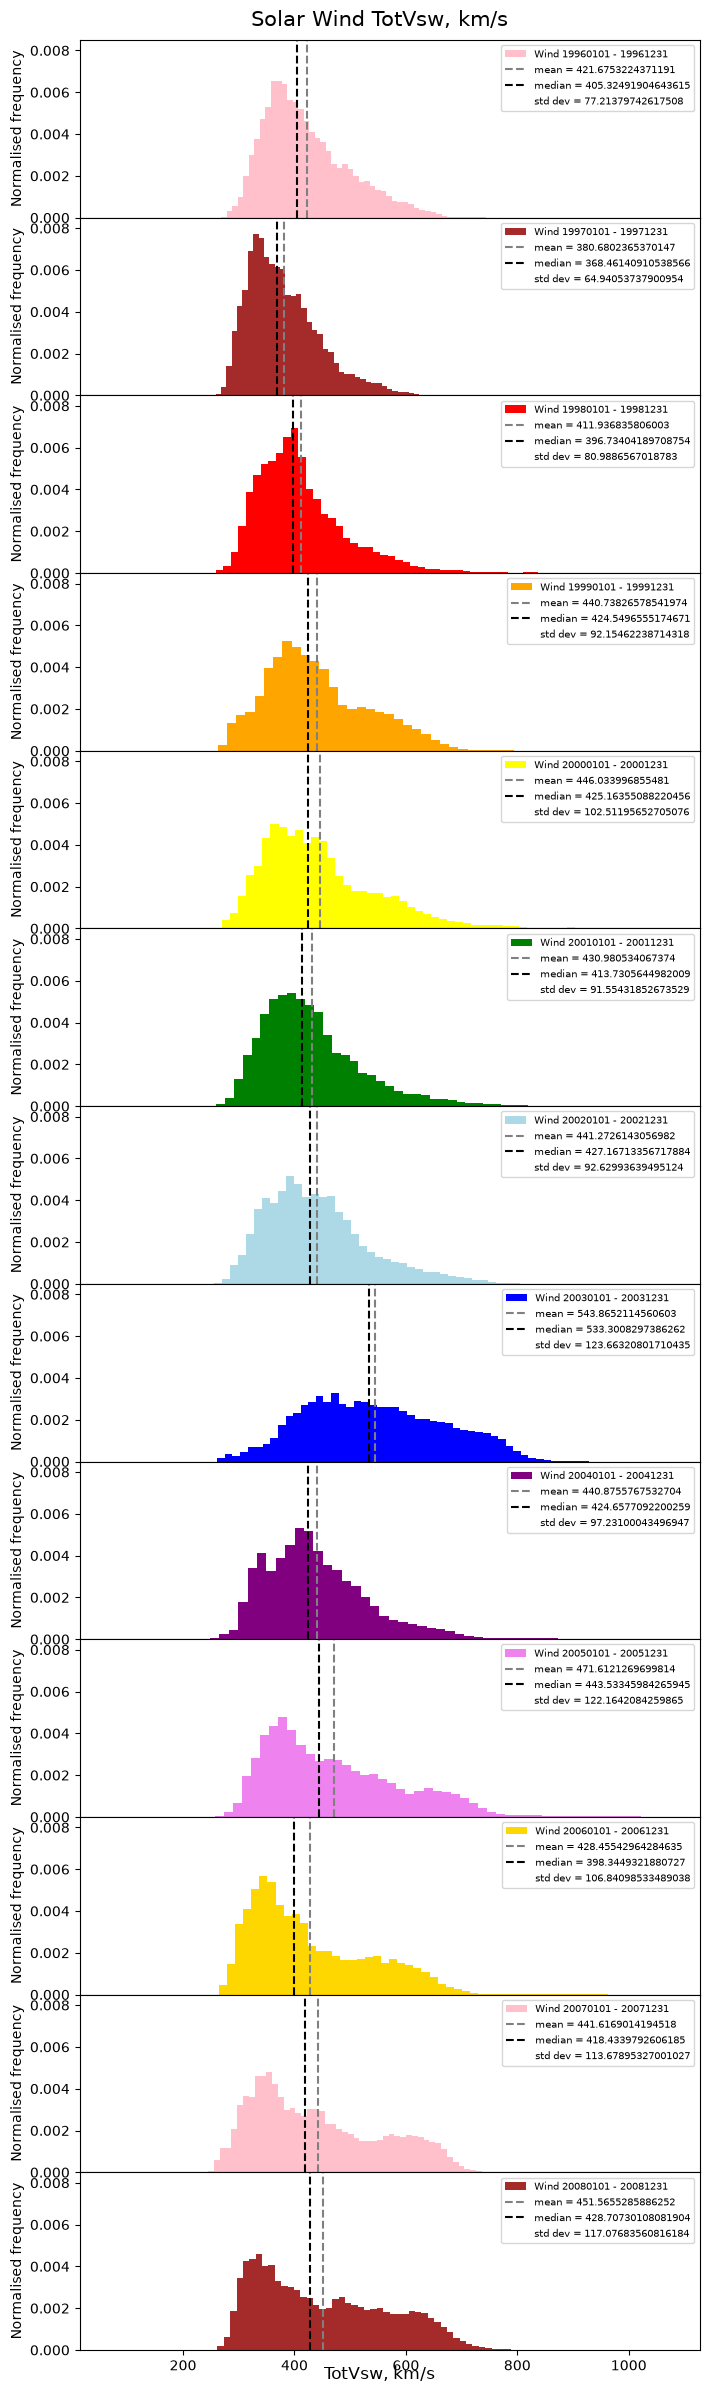

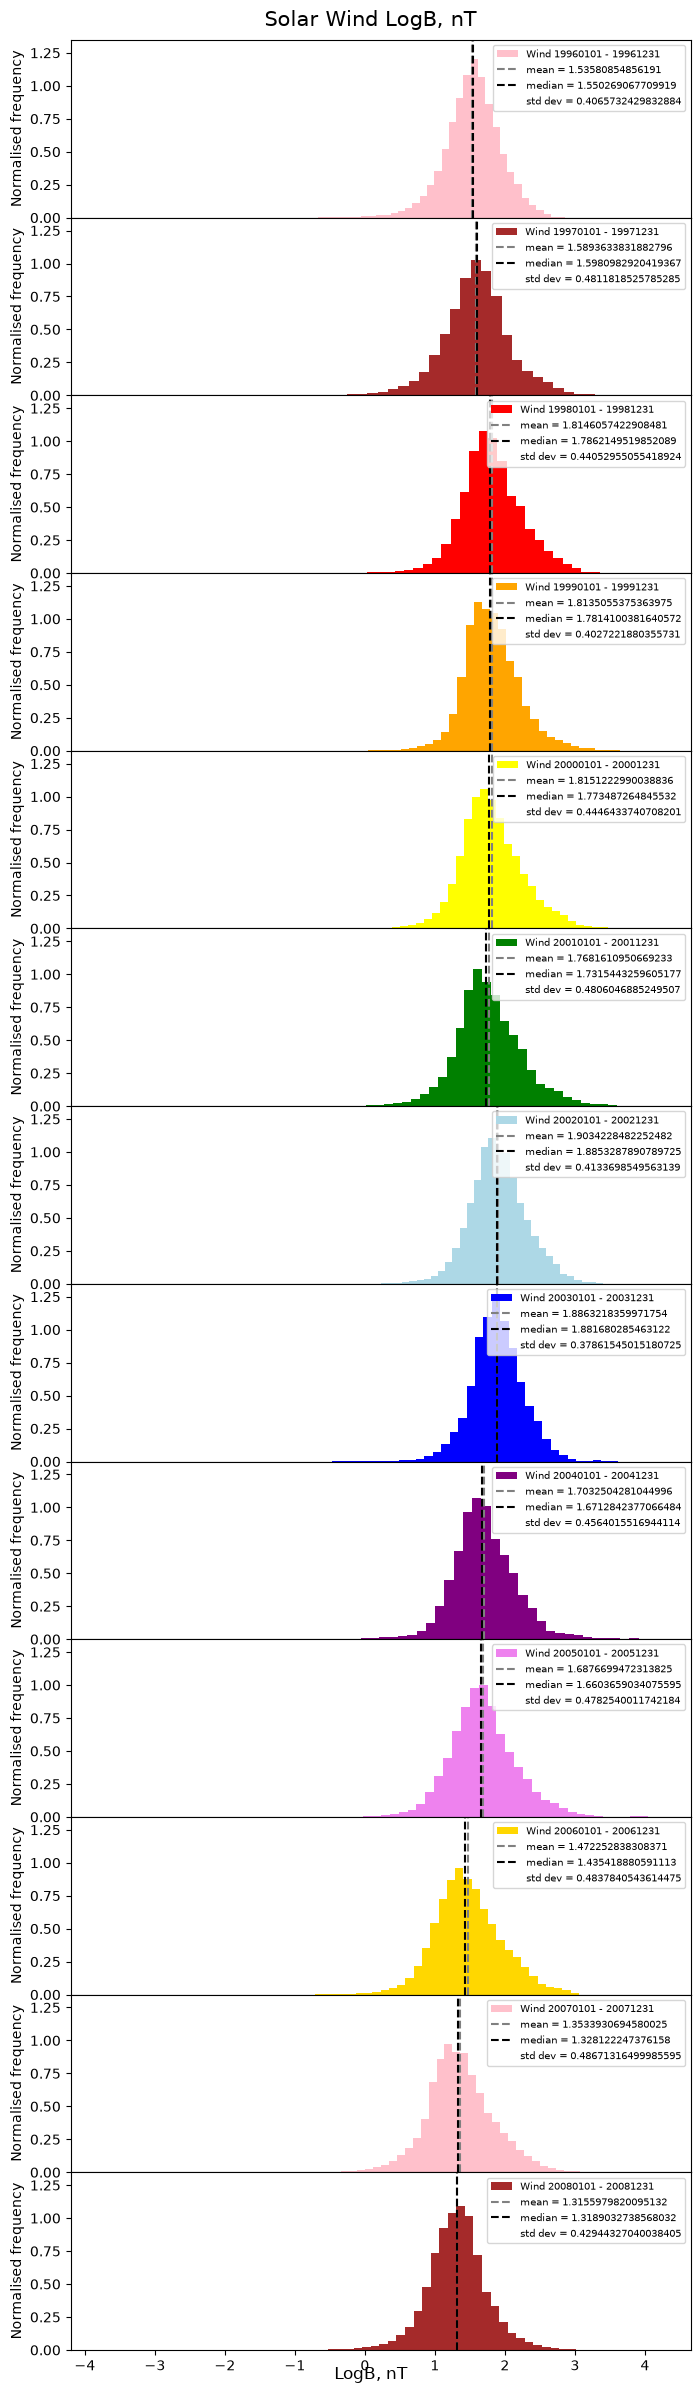

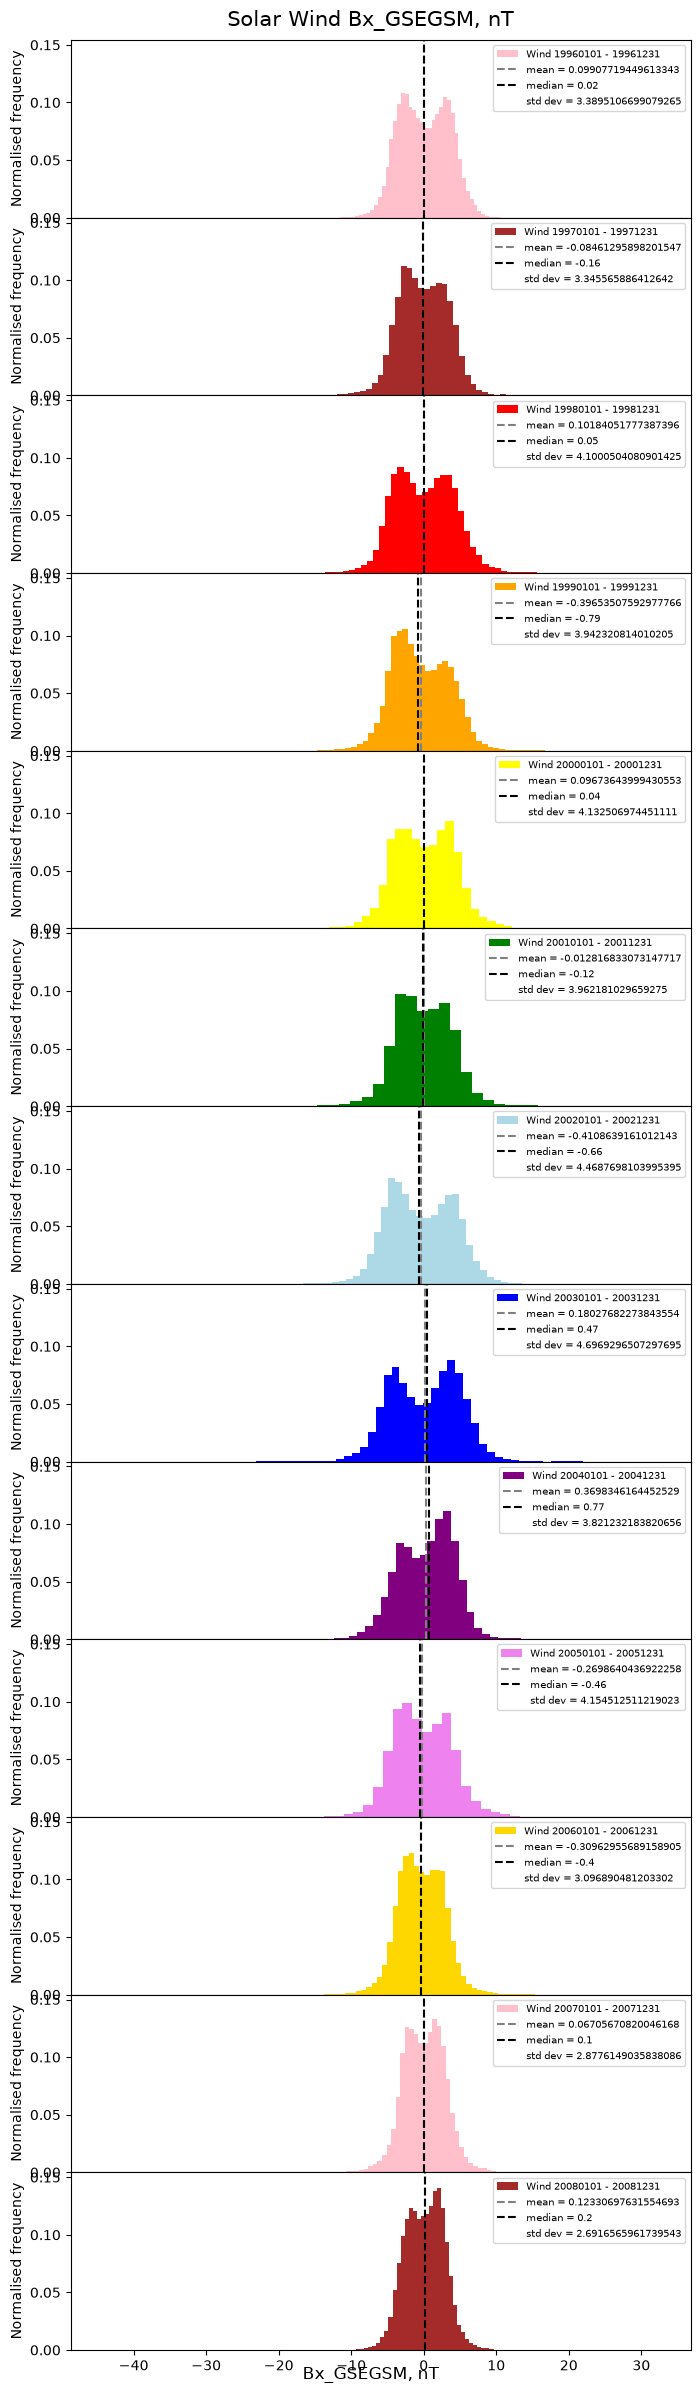

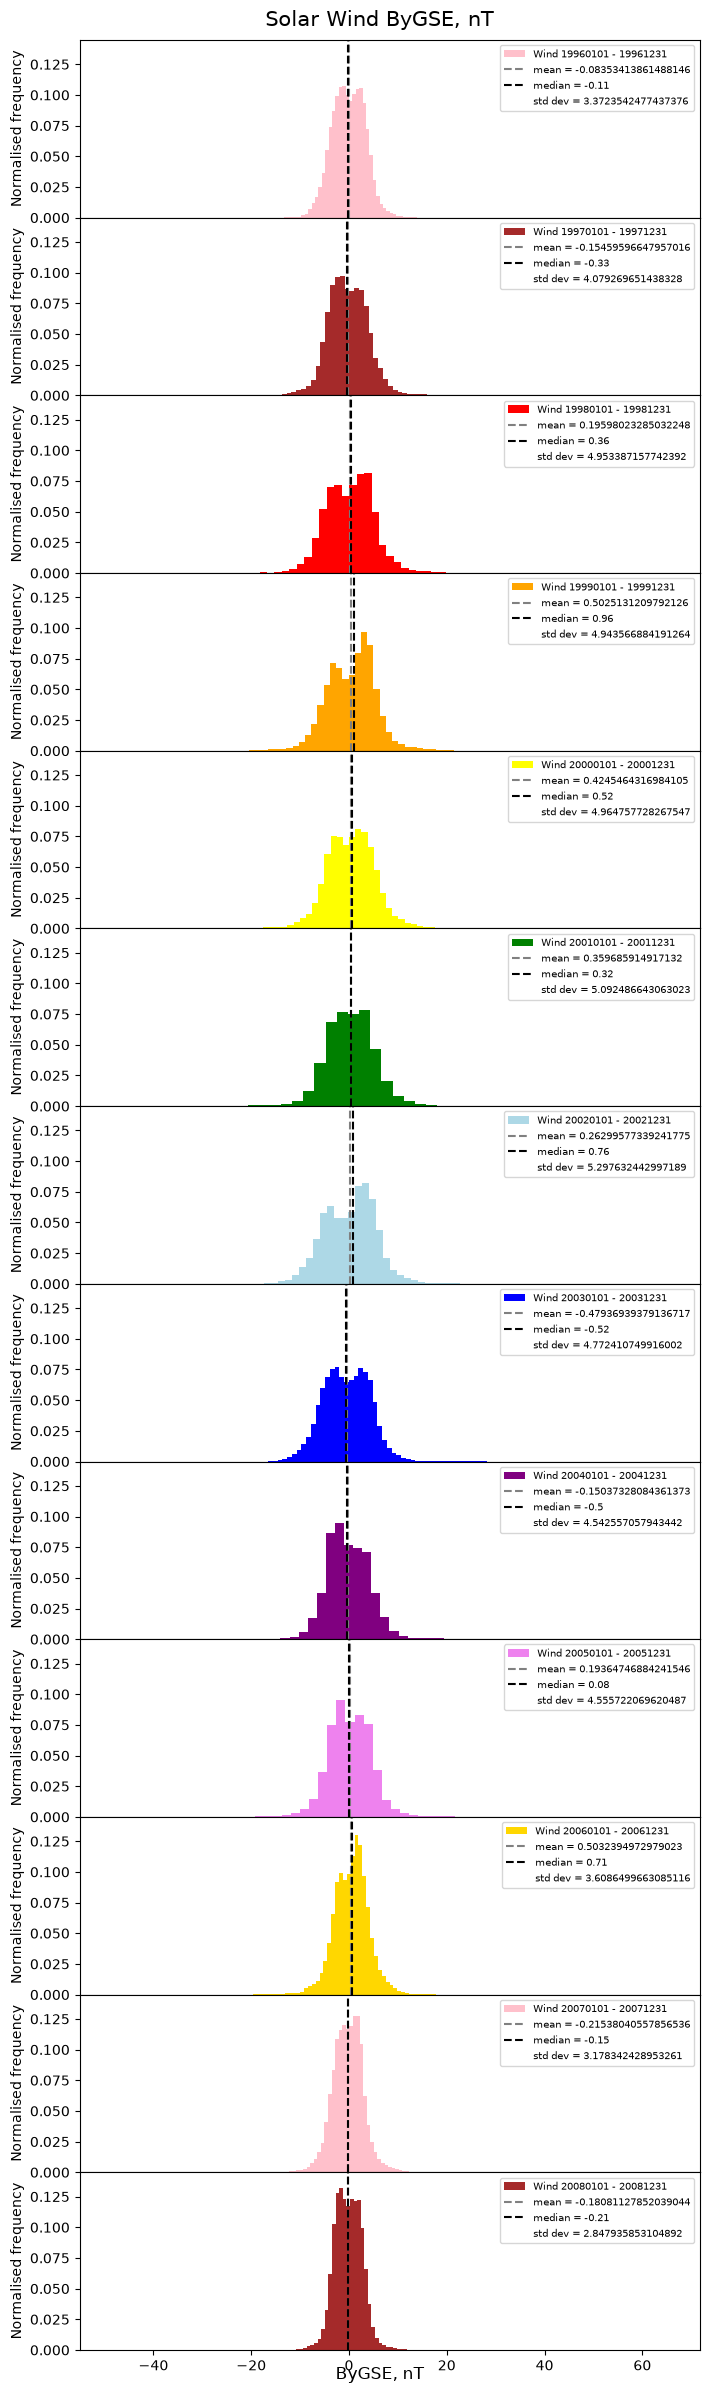

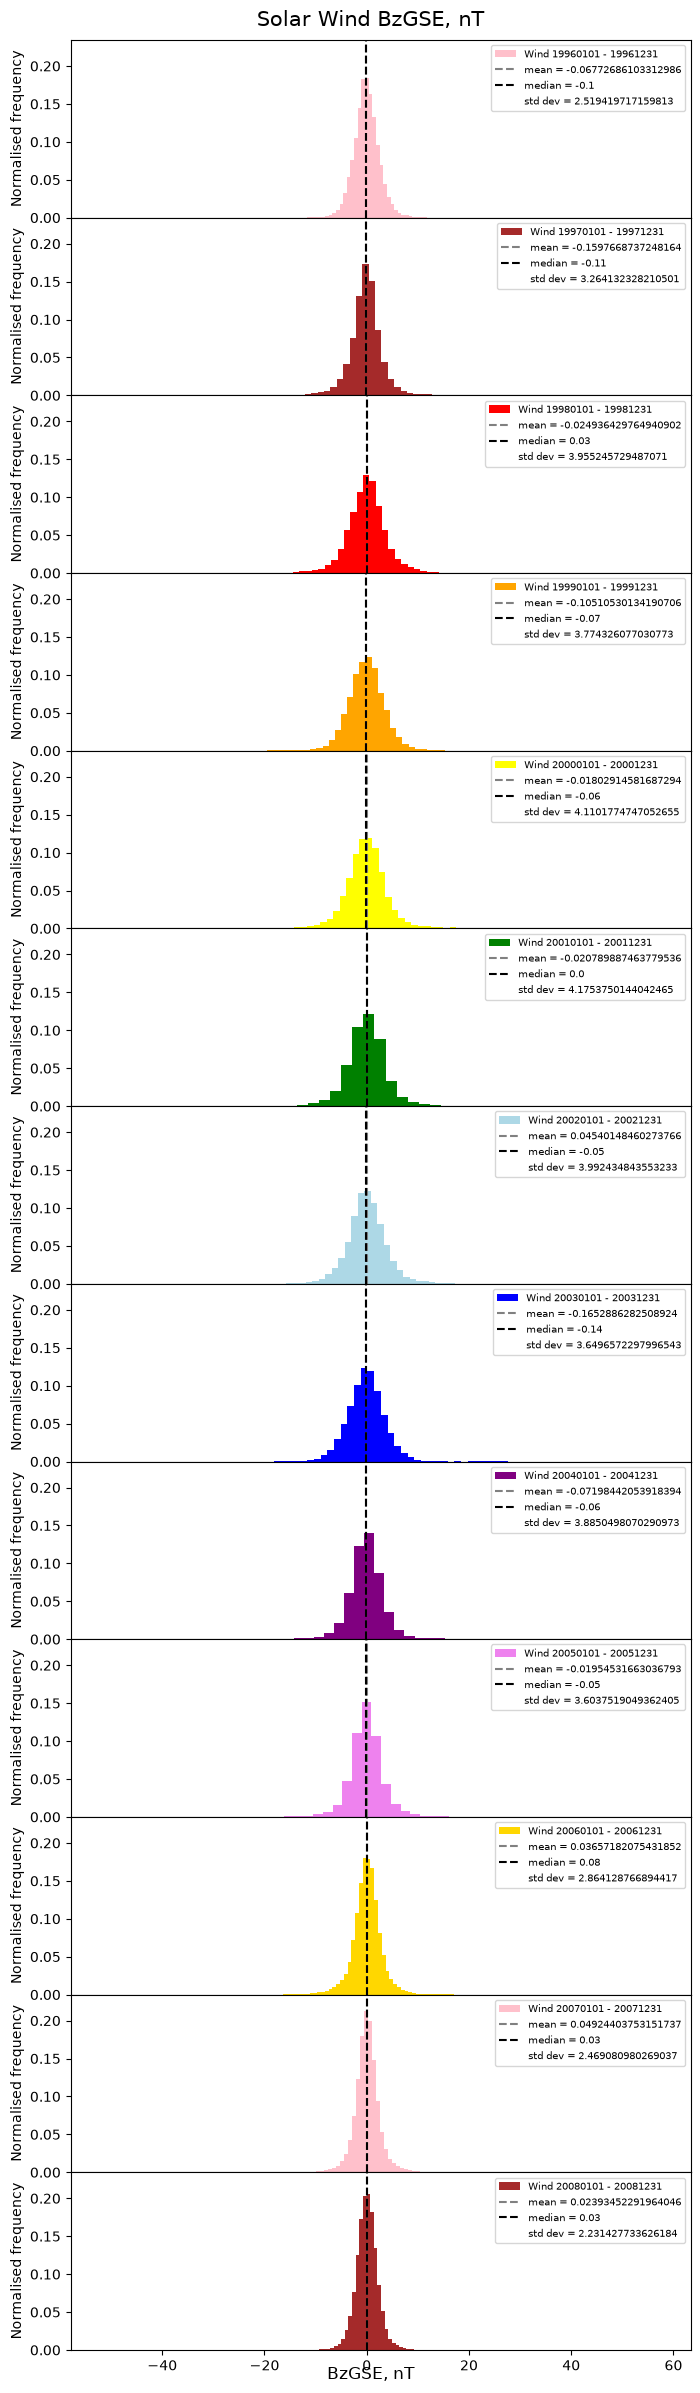

In [7]:
# Histogram formatting - Separate

Bin = 50
Alpha = 1
SupTitle = 15
Legend = 7.5
figSize = (8,30)
LegLoc = 'upper right'
SpaceLR = [100, 5, 5, 5, 5]
# Colours = ["red", "orange", "green", "blue"]
Colours = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']

    # "Bx_GSEGSM", "ByGSE", "BzGSE"
# dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
XAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "log", "log", "log", "log"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]


# PlotHistSeparate(dataTimeSerieses, Plotting)

PlotHistSeparate(dataTimeSerieses[0:13], Plotting, XAxisScale, YAxisScale, figSize)
# PlotHistSeparate(dataTimeSerieses[13:25], Plotting)
# PlotHistSeparate(dataTimeSerieses[25:], Plotting)


# #Find DateRanges for each file needed found
# def ReadDates(startDate, endDate): #ReadDatesForFileFinding
#     DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
#     return DateRange

# Years overlapping


In [67]:
Cycle23 = dataTimeSerieses[0:11]
Cycle24 = dataTimeSerieses[11:22]
Cycle25 = dataTimeSerieses[22:30]

# print(Cycle23)
# print(dataTimeSerieses)
# PlotHistSeparate(dataTimeSerieses[13:25], Plotting)
# PlotHistSeparate(dataTimeSerieses[25:], Plotting)


In [ ]:
# #Plot histograms separately
# def YearOverlap(dataTS1, dataTS2, dataTS3, VarsToPlot, NoOfYears, FigSize, TitleLoc, startYear): #, startSplit, endSplit):
    
#     for i in range(len(VarsToPlot)):
#         fig, axs = plt.subplots(NoOfYears,1, figsize=FigSize, sharex=True)
#         fig.subplots_adjust(hspace=0)
#         # plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
#         fig.supxlabel("Wind Data" + VarsToPlot[i] + ", " + Units[i], y=TitleLoc)
#         # subplotLabels = []

#         maxYInDf1 = 0
#         maxYInDf2 = 0
#         maxYInDf3 = 0
#         for j in range(len(dataTS1)):
#         # for j in range(startSplit, endSplit):

#             # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#             y, x, _ = axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True)
#             maxInYear = y.max()
#             if maxInYear > maxYInDf1:
#                 maxYInDf1 = maxInYear

#             # C23
#             #Mean
#             axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
#             #Median
#             axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
#             #Standard deviation
#             axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


#             if j < len(dataTS2):
#                 axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True)
#                 maxInYear = y.max()
#                 if maxInYear > maxYInDf2:
#                     maxYInDf2 = maxInYear

#                 # C24
#                 #Mean
#                 axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


#             if j < len(dataTS3):
#                 axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

#                 y, x, _ = axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True)
#                 maxInYear = y.max()
#                 if maxInYear > maxYInDf3:
#                     maxYInDf3 = maxInYear

#                 # C25
#                 #Mean
#                 axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
#                 #Median
#                 axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
#                 #Standard deviation
#                 axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

#         # for j in range(len(NoOfYears)):
#         #     if j < len(dataTS):
#             axs[j].legend(loc = LegLoc, fontsize = Legend)
#             axs[j].set_ylabel("Normalised frequency")

#             # subplotLabels.append("Year" + str(j))
#             axs[j].annotate("Year " + str(startYear + j), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))


#             # fig, axs = plt.subplot_mosaic([['a)', 'c)'], ['b)', 'c)'], ['d)', 'd)']], layout='constrained')
#             # for label, ax in axs.items():
#             #     ax.annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

#         # maxYInDf1 = 0
#         # for k in range(len(dataTS1)): # For each daterange
#         #     maxInYear = max(dataTS1[k]._data[VarsToPlot[i]])

#         #     if maxInYear > maxYInDf1:
#         #         maxYInDf1 = maxInYear

#         # maxYInDf2 = 0
#         # for l in range(len(dataTS2)): # For each daterange
#         #     maxInYear = max(dataTS2[l]._data[VarsToPlot[i]])
            
#         #     if maxInYear > maxYInDf2:
#         #         maxYInDf2 = maxInYear

#         # maxYInDf3 = 0
#         # for m in range(len(dataTS3)): # For each daterange
#         #     maxInYear = max(dataTS3[m]._data[VarsToPlot[i]])
            
#         #     if maxInYear > maxYInDf3:
#         #         maxYInDf3 = maxInYear
            
#         maxYsInDfs = [maxYInDf1, maxYInDf2, maxYInDf3]
#         maxYOverall = max(maxYsInDfs)
#         for j in range(len(dataTS1)):
#             axs[j].set_ylim(0, maxYOverall)

            
#             #     # axs[1].legend(loc = LegLoc, fontsize = Legend)
#             #     # axs[2].legend(loc = LegLoc, fontsize = Legend)
#             #     # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
#             # # LowerBounds.append(min(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
#             # # UpperBounds.append(max(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
#             # # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # axs[j].set_ylabel("Normalised frequency")
        

#         # # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
#         # # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

#         # plt.xscale(XAxisScale[i])
        

#         # # for m in range(len(dataTimeSerieses)):
#         # #     if maxY == np.nan or maxY == np.inf:
#         # #             print("Max is nan or inf.")
#         #     # else:
#         # for m in range(len(dataTimeSerieses)):
#         #     # axs[m].set_ylim(0, maxY)
#         #     axs[m].set_ylim(0, maxY+ 0.1*maxY)
#         # # plt.tight_layout()
#         # plt.yscale(YAxisScale[i])
        
#         # plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
#         plt.show()

In [69]:
# Bin = 50
# Alpha = 1
# SupTitle = 15
# Legend = 7.5
# # figSize = (10, 35) # for 11 plots
# figSize6 = (10, 35 *(6/11)) # for 6 plots
# figSize5 = (10, 35 *(5/11)) # for 5 plots

# LegLoc = 'upper right'
# titleLoc = 0.9
# SpaceLR = [100, 5, 5, 5, 5]
# # Colours = ["red", "orange", "green", "blue"]
# Colours = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']

#     # "Bx_GSEGSM", "ByGSE", "BzGSE"
# # dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# XAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# # YAxisScale = ["linear", "log", "log", "log", "log"]
# # YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# # XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
# # Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# # Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# # StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]
# noOfYears = 11

# # Cycle23 = dfToSeries(Cycle23)
# # Cycle24 = dfToSeries(Cycle24)
# # Cycle25 = dfToSeries(Cycle25)

# # YearOverlap(Cycle23, Cycle24, Cycle25, Plotting, noOfYears, figSize, titleLoc, 1)
# YearOverlap(Cycle23[0:6], Cycle24[0:6], Cycle25[0:6], Plotting, 6, figSize6, titleLoc, 1) #, 0, 6)
# YearOverlap(Cycle23[6:11], Cycle24[6:11], Cycle25[6:8], Plotting, 5, figSize5, titleLoc, 7) #, 6, 11)

In [89]:
#Plot histograms separately - sharing y axis that checks across all years
def YearOverlapGlobalYAxis(dataTS1, dataTS2, dataTS3, VarsToPlot, FigSize, TitleLoc, startSplit1, endSplit1, startSplit2, endSplit2):
    
    for i in range(len(VarsToPlot)):

        fig, axs = plt.subplots( (endSplit1-startSplit1) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit1-startSplit1)/11), sharex=True)
        fig.subplots_adjust(hspace=0)
        plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.9)
        fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
        # subplotLabels = []

        maxYInDf11 = 0
        maxYInDf21 = 0
        maxYInDf31 = 0
        maxYInDf12 = 0
        maxYInDf22 = 0
        maxYInDf32 = 0
        # for j in range(len(dataTS1)):
        for j in range(startSplit1, endSplit1):

            # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

            y, x, _ = axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True)
            maxInYear = y.max()
            if maxInYear > maxYInDf11:
                maxYInDf11 = maxInYear

            # C23
            #Mean
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
            #Median
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
            #Standard deviation
            axs[j].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


            if j < len(dataTS2):
                # axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf21:
                    maxYInDf21 = maxInYear

                # C24
                #Mean
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


            if j < len(dataTS3):
                # axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs[j].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf31:
                    maxYInDf31 = maxInYear

                # C25
                #Mean
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs[j].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

        # for j in range(len(NoOfYears)):
        #     if j < len(dataTS):
            axs[j].legend(loc = LegLoc, fontsize = Legend)
            axs[j].set_ylabel("Normalised frequency")

            # subplotLabels.append("Year" + str(j))
            axs[j].annotate("Year " + str(j + 1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))


            # fig, axs = plt.subplot_mosaic([['a)', 'c)'], ['b)', 'c)'], ['d)', 'd)']], layout='constrained')
            # for label, ax in axs.items():
            #     ax.annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

        # maxYInDf1 = 0
        # for k in range(len(dataTS1)): # For each daterange
        #     maxInYear = max(dataTS1[k]._data[VarsToPlot[i]])

        #     if maxInYear > maxYInDf1:
        #         maxYInDf1 = maxInYear

        # maxYInDf2 = 0
        # for l in range(len(dataTS2)): # For each daterange
        #     maxInYear = max(dataTS2[l]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf2:
        #         maxYInDf2 = maxInYear

        # maxYInDf3 = 0
        # for m in range(len(dataTS3)): # For each daterange
        #     maxInYear = max(dataTS3[m]._data[VarsToPlot[i]])
            
        #     if maxInYear > maxYInDf3:
        #         maxYInDf3 = maxInYear
            
        
        fig, axs2 = plt.subplots( (endSplit2-startSplit2) , 1, figsize=(FigSize[0], FigSize[1]*(endSplit2-startSplit2)/11), sharex=True)
        fig.subplots_adjust(hspace=0)
        plt.suptitle("Wind Data, " + VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.9)
        fig.supxlabel(VarsToPlot[i] + ", " + Units[i], y=0.085)
        # subplotLabels = []

        for j in range(startSplit2, endSplit2):

            # fig, axs = plt.subplots( (endSplit2-startSplit2) , 1, figsize=FigSize, sharex=True)
            # fig.subplots_adjust(hspace=0)
            # # plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", " + Units[i], fontsize = SupTitle, y=0.89)
            # fig.supxlabel("Wind Data" + VarsToPlot[i] + ", " + Units[i], y=TitleLoc)
            # # subplotLabels = []

            axNo = j-startSplit2

            # axs[j].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

            y, x, _ = axs2[axNo].hist(dataTS1[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'orange', label = "Cycle 23", density = True)
            maxInYear = y.max()
            if maxInYear > maxYInDf12:
                maxYInDf12 = maxInYear

            # C23
            #Mean
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "orange", label="mean = " + str(round(dataTS1[j]._data[VarsToPlot[i]].mean(), 2)))
            #Median
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "orange", label="median = " + str(round(dataTS1[j]._data[VarsToPlot[i]].median(),2)))
            #Standard deviation
            axs2[axNo].axvline(dataTS1[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS1[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


            if j < len(dataTS2):
                # axs[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs2[axNo].hist(dataTS2[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'green', label = "Cycle 24", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf22:
                    maxYInDf22 = maxInYear

                # C24
                #Mean
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "green", label="mean = " + str(round(dataTS2[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "green", label="median = " + str(round(dataTS2[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs2[axNo].axvline(dataTS2[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS2[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)


            if j < len(dataTS3):
                # axs[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True) #, label = "Wind " + str(StartAndEnd[j][0][0:10]) + " - " + str(StartAndEnd[j][1][0:10]), color=Colours[j], alpha = Alpha, density = True))

                y, x, _ = axs2[axNo].hist(dataTS3[j]._data[VarsToPlot[i]], bins = Bin, histtype='step', color = 'blue', label = "Cycle 25", density = True)
                maxInYear = y.max()
                if maxInYear > maxYInDf32:
                    maxYInDf32 = maxInYear

                # C25
                #Mean
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "blue", label="mean = " + str(round(dataTS3[j]._data[VarsToPlot[i]].mean(), 2)))
                #Median
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].median(), linestyle = ':', color = "blue", label="median = " + str(round(dataTS3[j]._data[VarsToPlot[i]].median(), 2)))
                #Standard deviation
                axs2[axNo].axvline(dataTS3[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(round(dataTS3[j]._data[VarsToPlot[i]].std(), 2)), alpha = 0)

        # for j in range(len(NoOfYears)):
        #     if j < len(dataTS):
            axs2[axNo].legend(loc = LegLoc, fontsize = Legend)
            axs2[axNo].set_ylabel("Normalised frequency")

            # subplotLabels.append("Year" + str(j))
            axs2[axNo].annotate("Year " + str(j+1), xy=(0, 1), xycoords='axes fraction', xytext=(+0.5, -0.5), textcoords='offset fontsize', fontsize='medium', verticalalignment='top', fontfamily='serif', bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))

        maxYsInDfs = [maxYInDf11, maxYInDf21, maxYInDf31, maxYInDf12, maxYInDf22, maxYInDf32]
        maxYOverall = max(maxYsInDfs)

        for j in range(startSplit1, endSplit1):
            # axs[j].set_ylim(0, maxYOverall)
            axs[j].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim


        for j in range(startSplit2, endSplit2):
            axNo = j-startSplit2
            # axs2[axNo].set_ylim(0, maxYOverall)
            axs2[axNo].set_ylim(0, maxYOverall*1.1) # adding 10% to y axis lim
        

        # # plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        # # plt.xlim(np.nanmin(LowerBounds) - SpaceLR[i], np.nanmax(UpperBounds) + SpaceLR[i])

        # plt.xscale(XAxisScale[i])
        

        # # for m in range(len(dataTimeSerieses)):
        # #     if maxY == np.nan or maxY == np.inf:
        # #             print("Max is nan or inf.")
        #     # else:
        # for m in range(len(dataTimeSerieses)):
        #     # axs[m].set_ylim(0, maxY)
        #     axs[m].set_ylim(0, maxY+ 0.1*maxY)
        # # plt.tight_layout()
        # plt.yscale(YAxisScale[i])
        
        # plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
        plt.show()

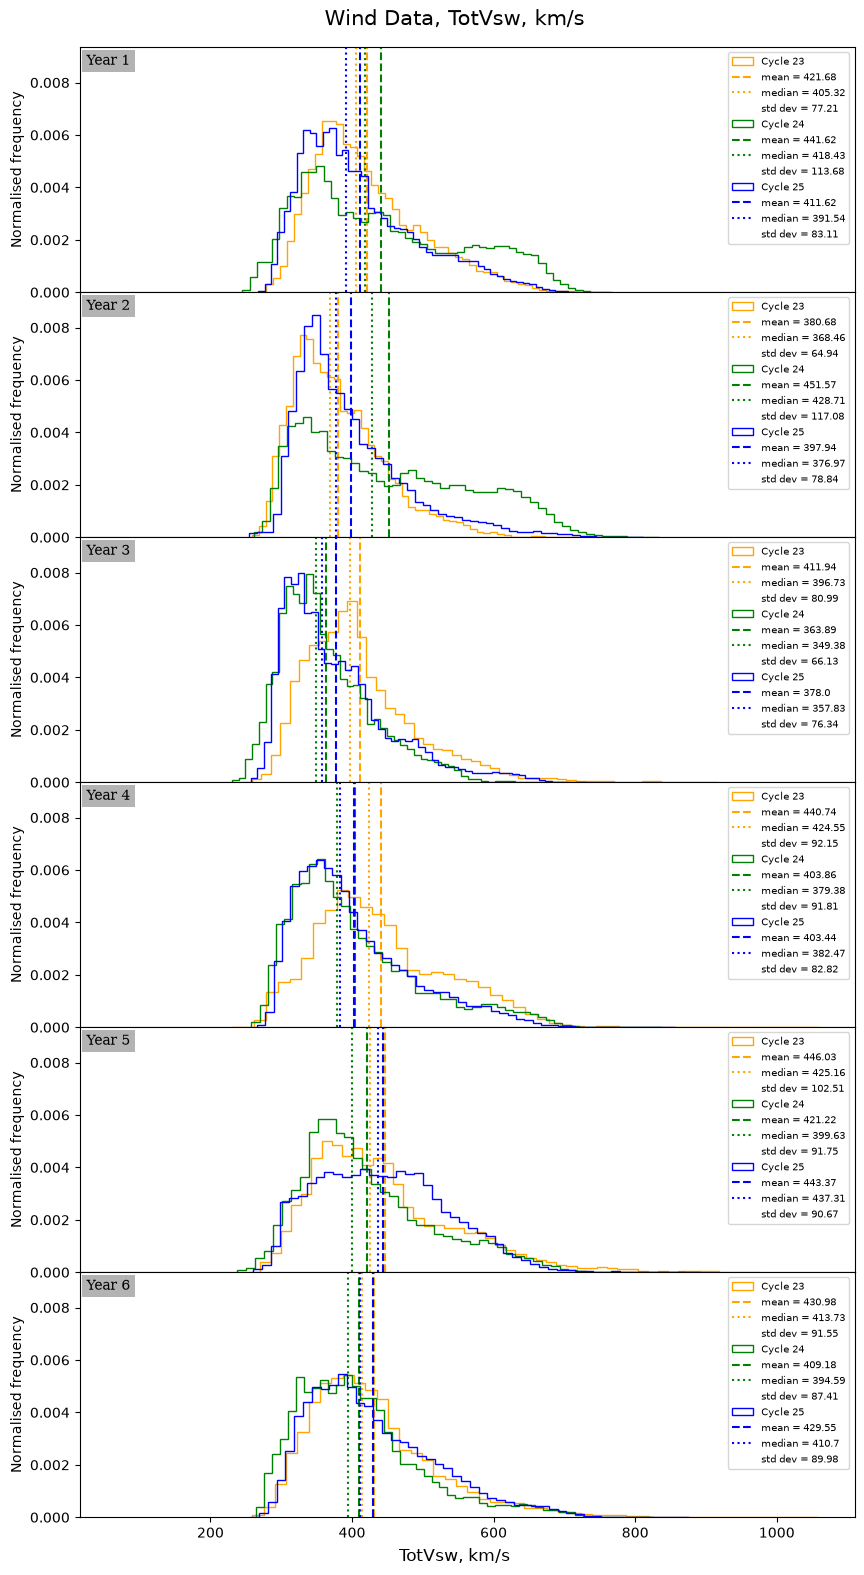

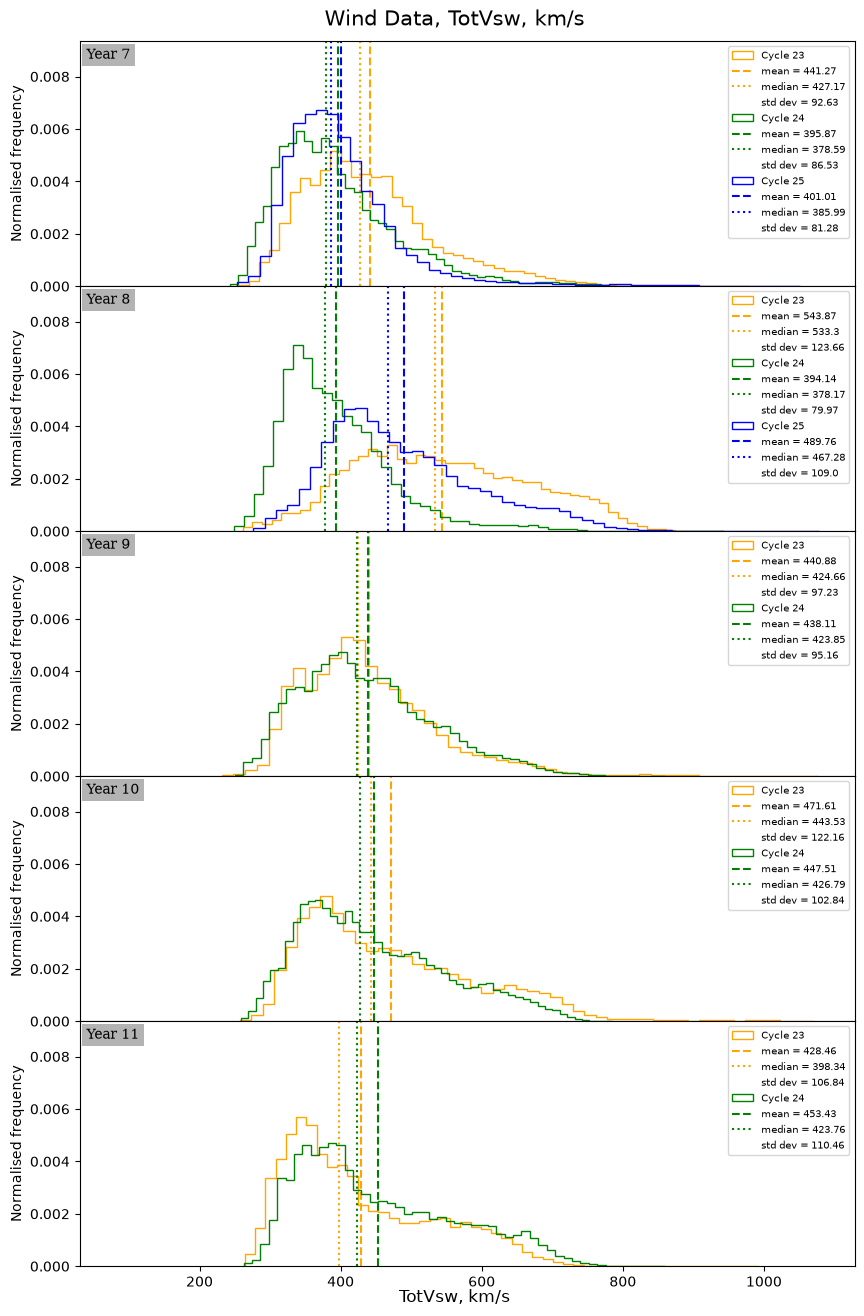

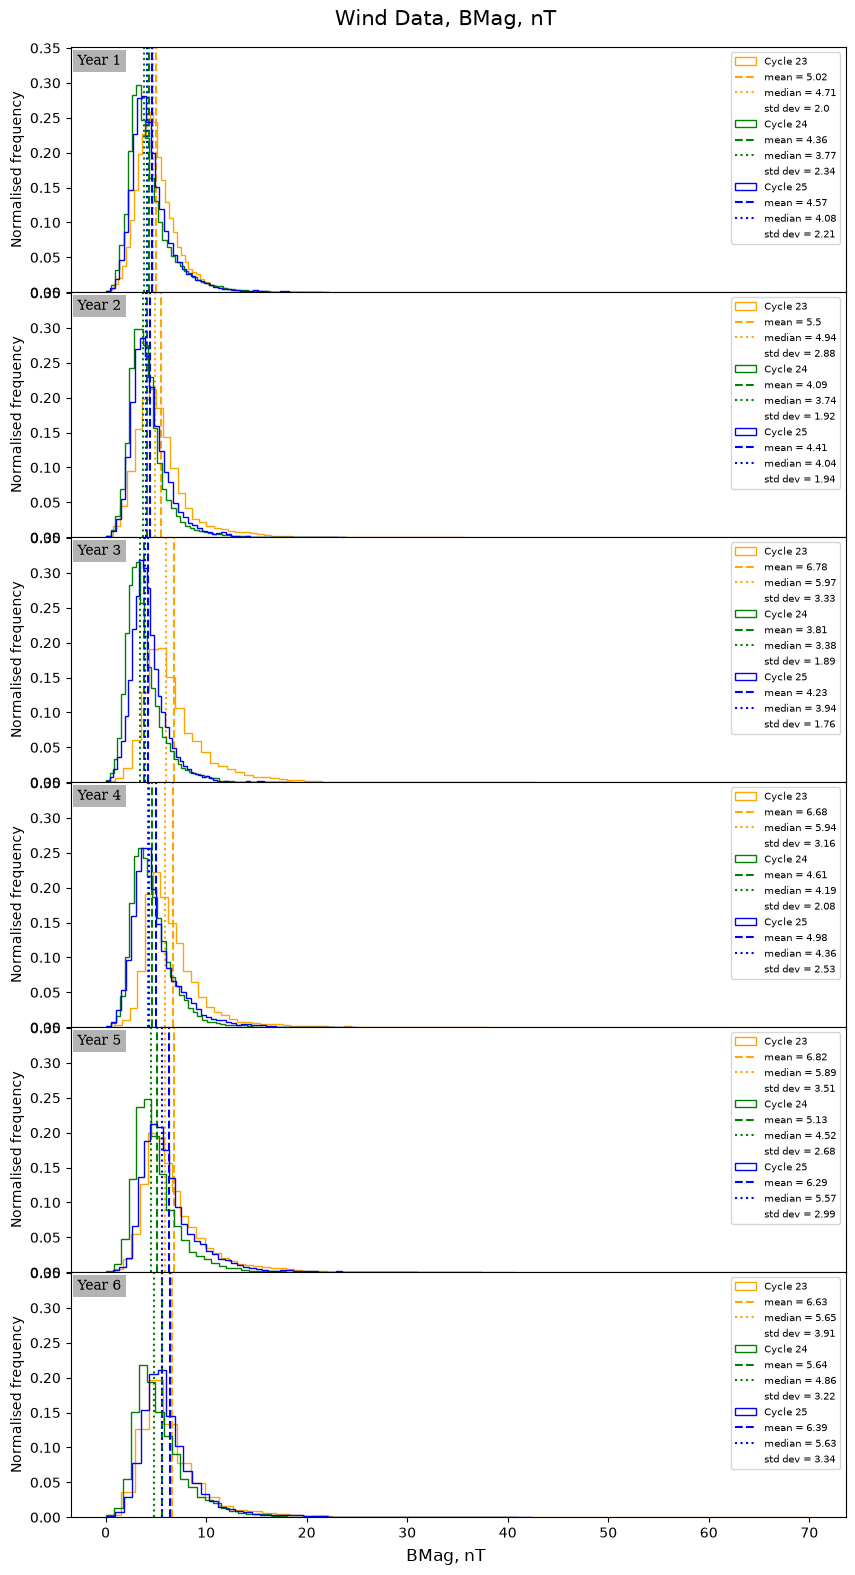

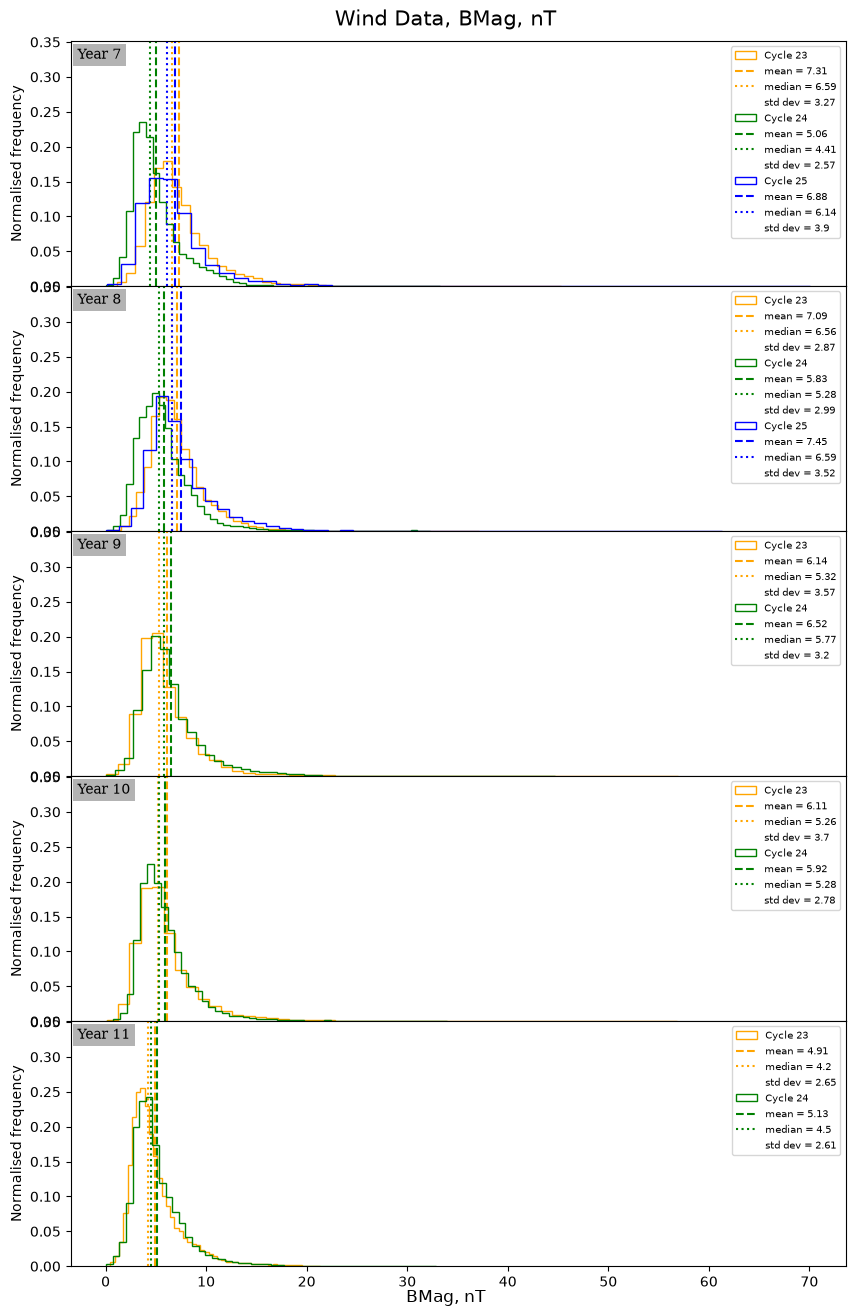

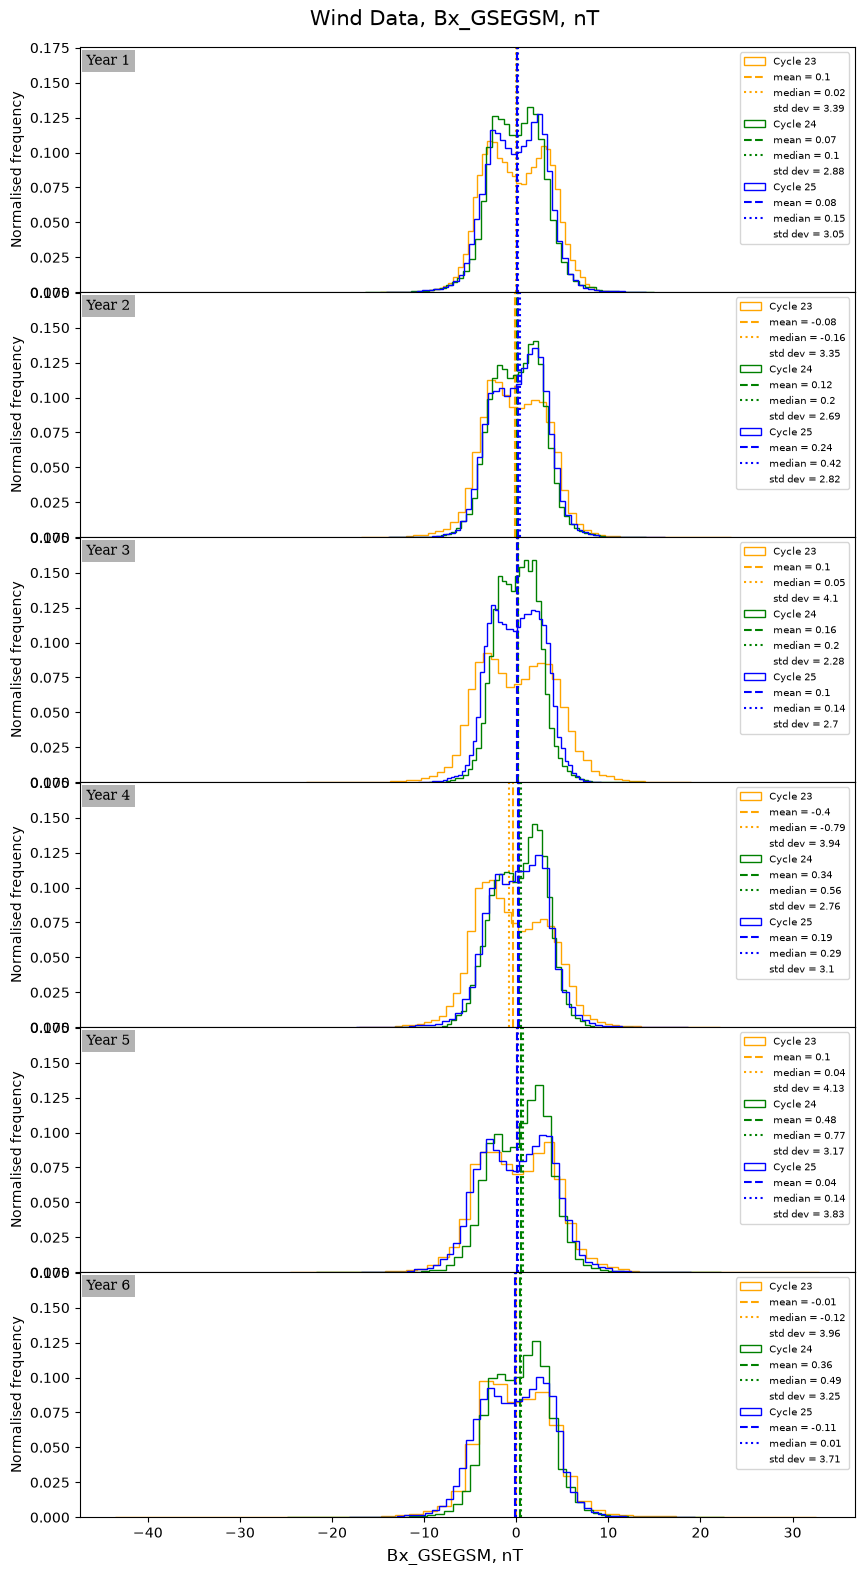

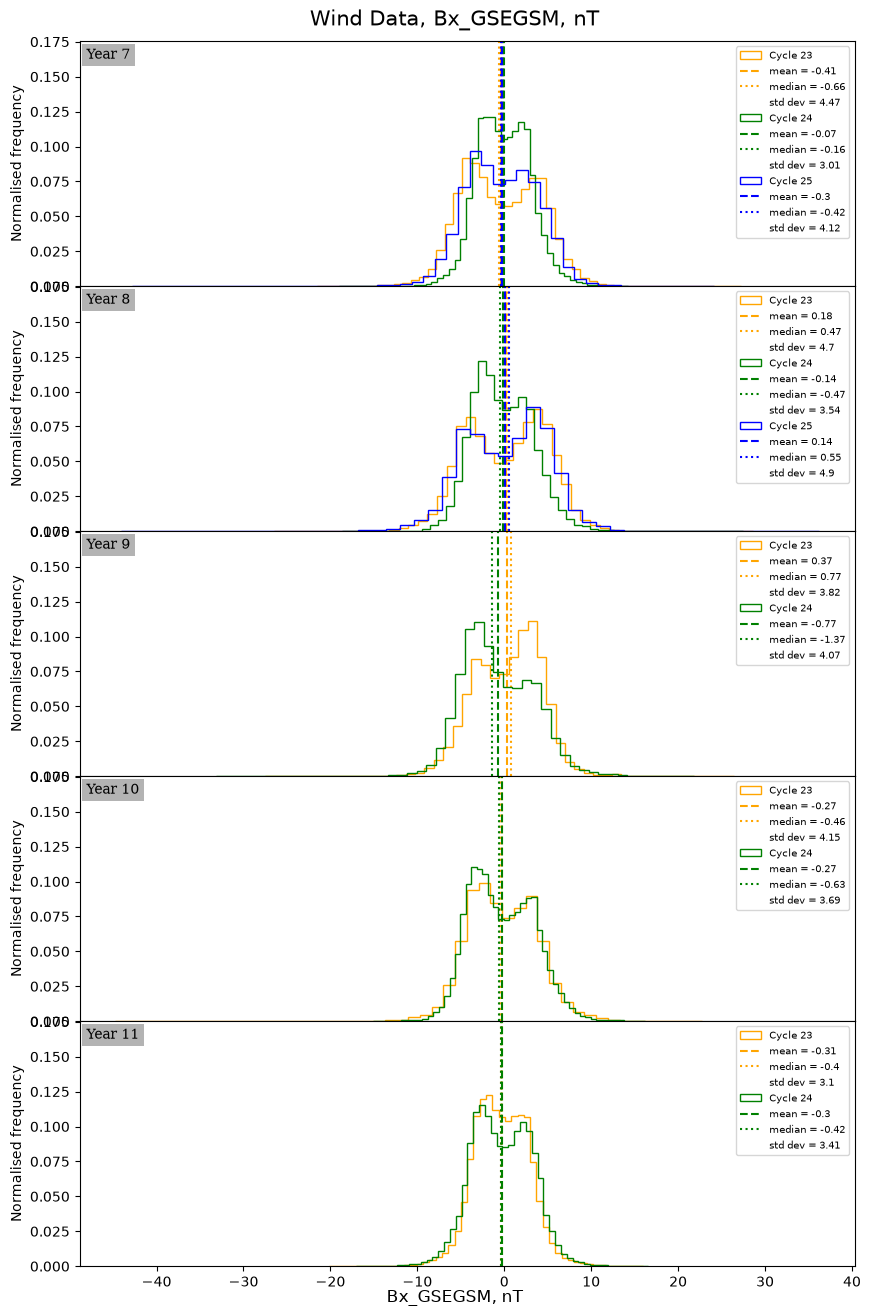

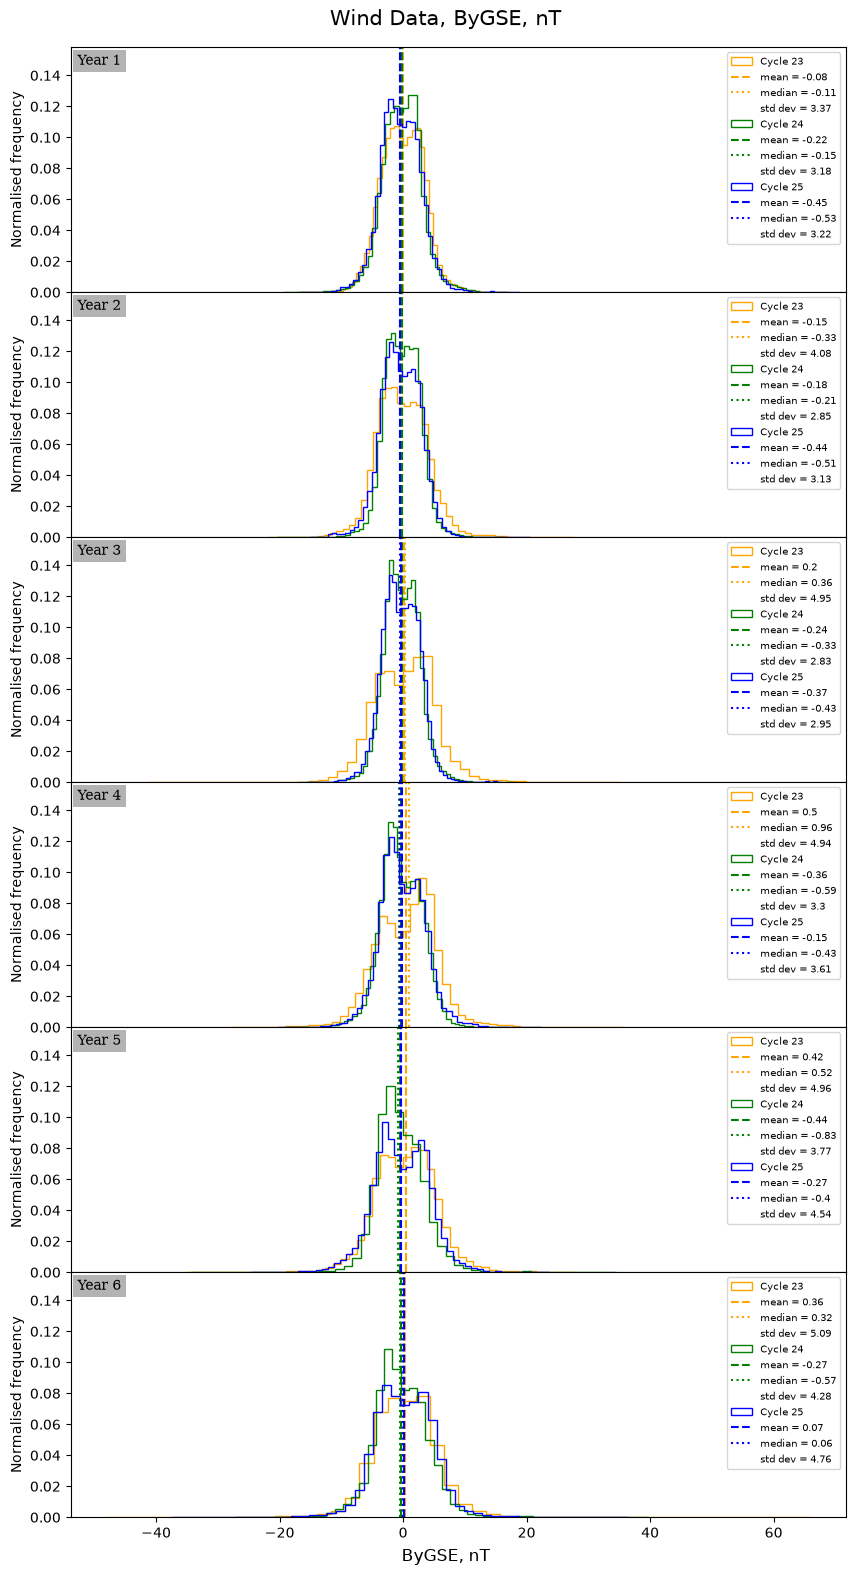

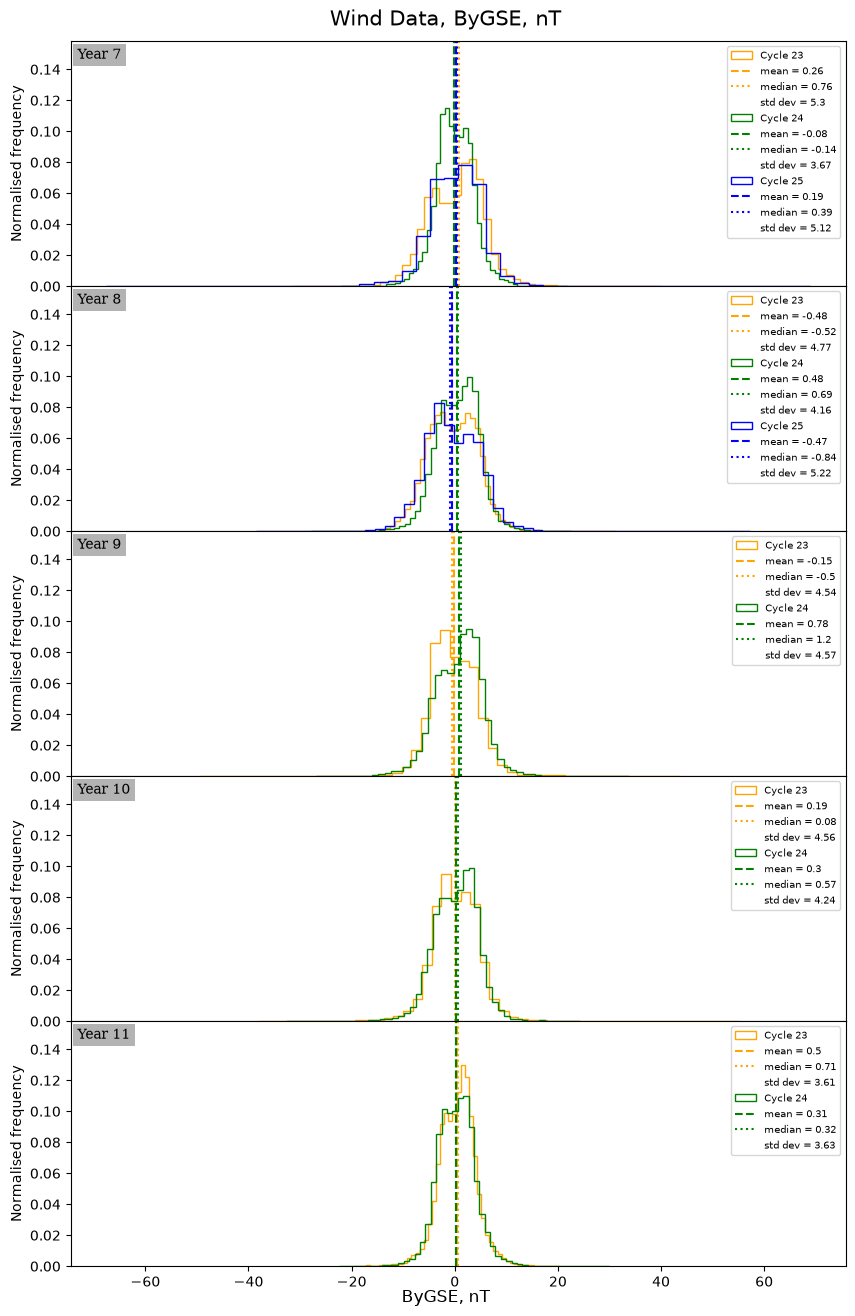

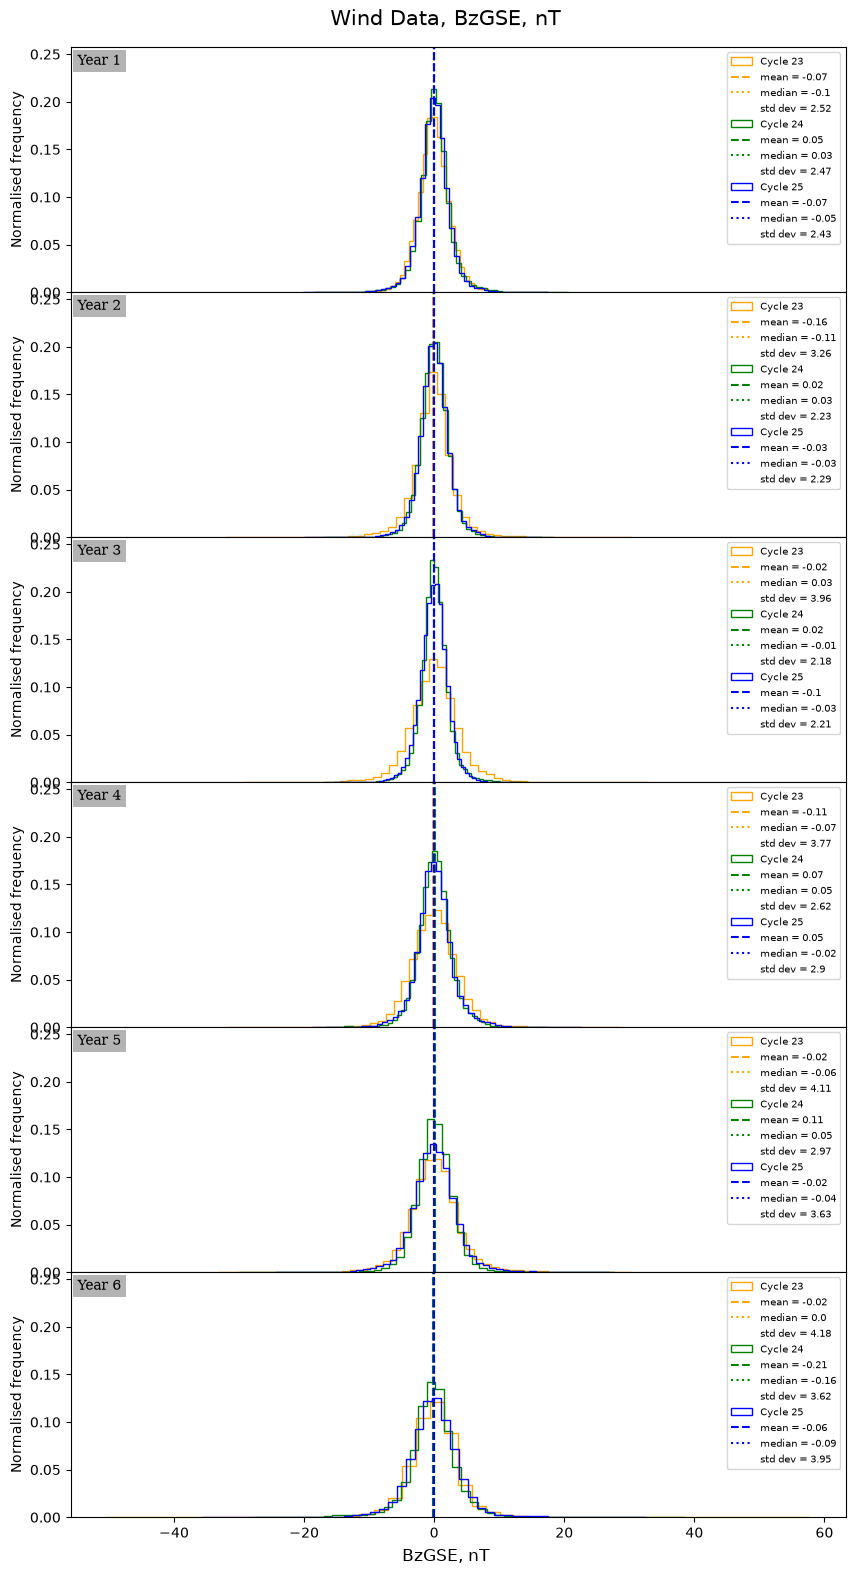

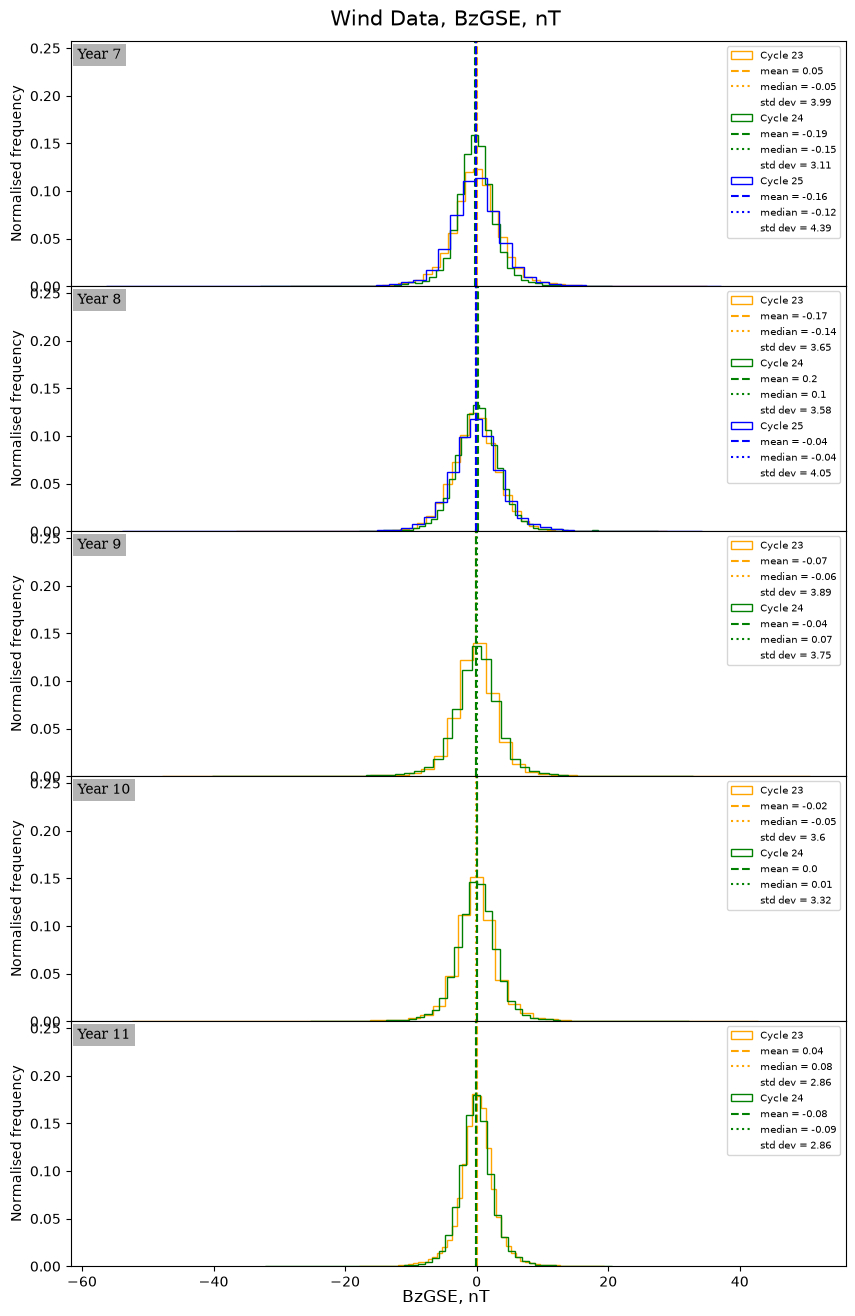

In [90]:
Bin = 50
Alpha = 1
SupTitle = 15
Legend = 7.5
figSize = (10, 35) # for 11 plots
# figSize6 = (10, 35 *(6/11)) # for 6 plots
# figSize5 = (10, 35 *(5/11)) # for 5 plots

LegLoc = 'upper right'
titleLoc = 0.9
SpaceLR = [100, 5, 5, 5, 5]
# Colours = ["red", "orange", "green", "blue"]
Colours = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink', 'brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']

    # "Bx_GSEGSM", "ByGSE", "BzGSE"
# dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
XAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
YAxisScale = ["linear", "linear", "linear", "linear", "linear"]#, "nT"]
# YAxisScale = ["linear", "log", "log", "log", "log"]
# YAxisScale = ["linear", "linear", "linear", "linear", "linear"]
# XAxisScale = ["linear", "log", "log", "log", "log"]#, "nT"]
# Plotting = ["TotVsw", "LogB", "Bx_GSEGSM", "ByGSE", "BzGSE"]#, "BZ_GSM"]
# Units = ["km/s", "nT", "nT", "nT", "nT"]#, "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]
noOfYears = 11

# Cycle23 = dfToSeries(Cycle23)
# Cycle24 = dfToSeries(Cycle24)
# Cycle25 = dfToSeries(Cycle25)

YearOverlapGlobalYAxis(Cycle23, Cycle24, Cycle25, Plotting, figSize, titleLoc, 0, 6, 6, 11)
# YearOverlap(Cycle23[0:6], Cycle24[0:6], Cycle25[0:6], Plotting, 6, figSize6, titleLoc, 1) #, 0, 6)
# YearOverlap(Cycle23[6:11], Cycle24[6:11], Cycle25[6:8], Plotting, 5, figSize5, titleLoc, 7) #, 6, 11)

In [ ]:
# dataTSC23Min.columns


## Get TotVsw and plot data to check by eye if it's what you expect

In [ ]:
# dataTSC23Min = AddTotVsw(dataTSC23Min)
# dataTSC23Max = AddTotVsw(dataTSC23Max)
# dataTSC24Min = AddTotVsw(dataTSC24Min)
# dataTSC24Max = AddTotVsw(dataTSC24Max)

In [ ]:
# dataTSC23Min = AddTotVsw(dataTSC23Min)
# PlotVsw(dataTSC23Min)
# print(np.sort(dataTSC23Min._data["Vx_GSE"].unique()))
# # print(dataTSC23Min._data["TotVsw"].unique())


In [ ]:
# PlotVsw(dataTSC23Min)
# PlotVsw(dataTSC23Max)
# PlotVsw(dataTSC24Min)
# PlotVsw(dataTSC24Max)

## BMag calculated

In [ ]:
# Get BMag and plot data to check by eye if it's what you expect
# dataTSC23Min = AddBMag(dataTSC23Min)
# dataTSC23Max = AddBMag(dataTSC23Max)
# dataTSC24Min = AddBMag(dataTSC24Min)
# dataTSC24Max = AddBMag(dataTSC24Max)

In [ ]:
# PlotB(dataTSC23Min)
# PlotB(dataTSC23Max)
# PlotB(dataTSC24Min)
# PlotB(dataTSC24Max)

# print(np.sort(dataTSC23Min._data["Bx_GSEGSM"].unique()))

## Dotted plots for extra checks

In [ ]:
# PlotVswDotted(dataTSC23Min)

## Histograms

### All together histograms

In [ ]:
# # Histogram formatting - all together
# Bin = 50
# Alpha = 0.5
# Legend = 7.5
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# # Plotting = ["TotVsw", "BMag", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]

# dataTimeSerieses = [dataTSC23Min, dataTSC23Max, dataTSC24Min, dataTSC24Max]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC24Max, endDateC24Max]]

# PlotHistTogether(dataTimeSerieses, Plotting)

### Separate histograms

In [ ]:
# # Histogram formatting - Separate
# Bin = 50
# Alpha = 1
# SupTitle = 15
# Legend = 7.5
# FigSize = (10,10)
# LegLoc = 'upper right'
# SpaceLR = [100, 5, 5, 5, 5]
# Colours = ["red", "orange", "green", "blue"]
# # dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
# dataTimeSerieses = [dataTSC23Min, dataTSC23Max, dataTSC24Min, dataTSC24Max]
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# # Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Units = ["km/s", "nT", "nT", "nT", "nT", "nT"]
# # StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]

# # PlotHistSeparate(dataTimeSerieses, Plotting)

# PlotHistSeparate(dataTimeSerieses, Plotting)

## CDFs

In [ ]:
# # CDF Formatting
# yLim = [-0.05,1.05]
# Legend = 7.5
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# # Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Unit = ["km/s", "nT", "nT", "nT", "nT"] #, "nT"]

# # PlotCDF(dataTimeSerieses, Plotting)
# PlotCDF(dataTimeSerieses, Plotting)

## Plotting DQQ and finding q values

### Plotting

In [ ]:
# Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# # Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Lims = [[250, 910], [0, 40], [-15, 30], [-15, 30], [-15, 30]]
# Unit = ["km/s", "nT", "nT", "nT", "nT"] #, "nT"]

# # Plotting = ["TotVsw", "BMag", "BX_GSE"]#, "BY_GSM", "BZ_GSM"]
# # Lims = [[250, 910], [0, 40], [-15, 30]]#, [-15, 30], [-15, 30]]
# Breakpoints = [ [[ 0.9960, 0.9995], [ 0.8660, 0.9980]], [[ 0.9990, 0.9750], [ 0.9990, 0.9970]], [[ 0.9980, 0.1100], [ 0.9980, 0.1100]]]
# dataTimeSeriesToCompare = [ [dataTSC23Min, dataTSC23Max], [dataTSC24Min, dataTSC24Max]]
# PlotLabels = ["C23", "C24"]
# Color = ["red", "blue"]

# PlotDQQ(dataTimeSeriesToCompare, Plotting, Breakpoints)

# Separated Fast and Slow Wind

In [ ]:
# # print(dataTimeSeriesToCompare)

# #Plot DQQ graphs with qs
# def PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific, SplitValue):
#     for i in range(len(VarsToPlot)): # do each parameter
#         fig, ax  = plt.subplots(1,2, figsize=(5, 5))
#         for j in range(len(dataTimeSeriesToCompare)): # do each comparison
#             dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
#             dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])

#             print(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])

#             # s = pl.Series("a", [1, 2, 3])
#             MaskingBelow = []
#             MaskingAbove = []
#             for m in range(len(dataTimeSeriesPS1)):
#                 if dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]][m] < SplitValue:
#                     MaskingBelow.append(True)
#                     MaskingAbove.append(False)
#                 else:
#                     MaskingBelow.append(False)
#                     MaskingAbove.append(True)

#             maskBelow = pl.Series("", MaskingBelow)
#             maskAbove = pl.Series("", MaskingAbove)

#             dataTimeSeriesPS1Below = dataTimeSeriesPS1.filter(maskBelow)
#             dataTimeSeriesPS1Above = dataTimeSeriesPS1.filter(maskAbove)  

#             xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
#             axs[0].scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
#             xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
#             axs[1].scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])

#             xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
#             xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)

#             if np.isnan(quantOfKneeBelow):
#                 print("---------------------------")
#                 print("Error finding breakpoints q")
#                 print("---------------------------")
#             else:
#                 plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black", label = "q = " + str(quantOfKneeBelow))
#                 # plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black")

#             if np.isnan(quantOfKneeAbove):
#                 print("---------------------------")
#                 print("Error finding breakpoints q")
#                 print("---------------------------")
#             else:
#                 plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black", label = "q = " + str(quantOfKneeAbove))
#                 # plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black")


#             # xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
#             # plt.scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
#             # xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
#             # plt.scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])
            
#             # xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
#             # xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)
            
#             # if np.isnan(quantOfKnee):
#             #     print("---------------------------")
#             #     print("Error finding breakpoints q")
#             #     print("---------------------------")
#             # else:
#             #     plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
#             #     # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
#         x = np.linspace(-100, 900, 2)
#         y = x

#         for aa in ax:
#             aa.plot(x, y, color="grey")
#             aa.legend(loc="lower right", fontsize = Legend)
#             aa.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
#             aa.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
#             aa.set_xlim(Lims[i])
#             aa.set_ylim(Lims[i])
        
#         ax[0].savefig("DQQBelow_Wind.png")
#         ax[1].savefig("DQQAbove_Wind.png")

#         plt.show()

#         # C23
#         # data_sortedPLSeriesXC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]]) # make data into a polar series
#         # data_sortedPLSeriesYC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]])

# PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, Plotting, Breakpoints, 450)

# Archived code

In [ ]:
# def PlotVswFiltered(dataTimeSeries, filter):
#     Filtered = dataTimeSeries._data[dataTimeSeries._data['TotVsw'] < filter]
#     FilteredTS = dfToSeries(Filtered)
#     # print(FilteredTS)
#     fig, ax = plt.subplots()
#     FilteredTS.plot(columns=["TotVsw", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE"], alpha = 0.5)
#     plt.legend(loc="upper right")
#     # plt.ylim(-450,900)

# PlotVswFiltered(dataTSC23Min, 10000)
# PlotVswFiltered(dataTSC23Max, 10000)
# PlotVswFiltered(dataTSC24Min, 10000)
# PlotVswFiltered(dataTSC24Max, 10000)

In [ ]:
# def PlotVswRemoveFiller(dataTimeSeries):
#     cols = ["FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE"]
#     fig, ax = plt.subplots()
#     for i in range(len(cols)):
#         Filtered = dataTimeSeries._data[dataTimeSeries._data[cols[i]] != 99999.9]
#         FilteredTS = dfToSeries(Filtered)
#         # print(FilteredTS)
#         FilteredTS.plot(columns=[cols[i]], alpha = 0.5)

#     plt.legend(loc="upper right")
#     plt.title(dataTimeSeries.time_range)
#     # plt.ylim(-450,900)

# def PlotBRemoveFiller(dataTimeSeries):
#     cols = ["ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
#     fig, ax = plt.subplots()
#     for i in range(len(cols)):
#         Filtered = dataTimeSeries._data[dataTimeSeries._data[cols[i]] != 9999.99]
#         FilteredTS = dfToSeries(Filtered)
#         # print(FilteredTS)
#         FilteredTS.plot(columns=[cols[i]], alpha = 0.5)

#     plt.legend(loc="upper right")
#     plt.title(dataTimeSeries.time_range)
#     # plt.ylim(-40,90)

# # Plot histograms all together
# def PlotHistTogetherRemoveFiller(dataTimeSerieses, VarsToPlot, Fillers):
#     for i in range(len(VarsToPlot)):
#         for j in range(len(dataTimeSerieses)):
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             plt.hist(FilteredTS._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0] + " - " + str(StartAndEnd[j][1])), alpha = Alpha, density = True)
#         plt.title("Solar Wind " + VarsToPlot[i])
#         plt.xlabel(VarsToPlot[i] + r", GSE, $km/s$")
#         plt.legend(fontsize=Legend)
#         plt.show()

# #Plot histograms separately
# def PlotHistSeparateRemoveFillers(dataTimeSerieses, VarsToPlot, Fillers):
#     for i in range(len(VarsToPlot)): # For each variable
#         LowerBounds = [] # set lower bounds array to 0
#         UpperBounds = [] # set upper bounds array to 0
#         fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
#         fig.subplots_adjust(hspace=0)
#         for j in range(len(dataTimeSerieses)): # For each daterange
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             axs[j].hist(FilteredTS._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j], alpha = Alpha, density = True)
#             #Mean
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].mean(), linestyle = '--', color = "grey", label="mean = " + str(FilteredTS._data[VarsToPlot[i]].mean()))
#             #Median
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].median(), linestyle = '--', color = "black", label="median = " + str(FilteredTS._data[VarsToPlot[i]].median()))
#             #Standard deviation
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(FilteredTS._data[VarsToPlot[i]].std()), alpha = 0)

#             axs[j].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[1].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[2].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
#             LowerBounds.append(min(FilteredTS._data[VarsToPlot[i]].values))
#             UpperBounds.append(max(FilteredTS._data[VarsToPlot[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
        
#         plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", ", fontsize = SupTitle)
#         fig.supxlabel(VarsToPlot[i] + ", " + str(Units[i]))

#         plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
#         plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
#         # plt.show()

# Plot CDF
# def PlotCDFRemoveFillers(dataTimeSerieses, VarsToPlot, Fillers):
#     # fig, axs = plt.subplots()#4,1, figsize=FigSize, sharex=True)
#     # fig.subplots_adjust(hspace=0)
#     for i in range(len(VarsToPlot)):
#         for j in range(len(dataTimeSerieses)):
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             sns.ecdfplot(FilteredTS._data[VarsToPlot[i]], label="Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j])
#         plt.xlabel(VarsToPlot[i] + ", " + Units[i])
#         plt.ylabel('Cumulative probability')
#         plt.ylim(yLim)
#         plt.legend(fontsize=Legend)
#         plt.grid(True)
#         plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_CDF_Wind.png") #  + dataTimeSerieses[0] + " - " + dataTimeSerieses[-1] 
#         plt.show()

# def PlotDQQRemoveFillers(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific, Fillers):
#     for i in range(len(VarsToPlot)): # do each parameter
#         fig, ax  = plt.subplots(figsize=(5, 5))
#         for j in range(len(dataTimeSeriesToCompare)): # do each comparison
#             Filtered1 = dataTimeSeriesToCompare[j][0]._data[dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS1 = dfToSeries(Filtered1)
#             Filtered2 = dataTimeSeriesToCompare[j][1]._data[dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS2 = dfToSeries(Filtered2)
#             dataTimeSeriesPS1 = pl.Series(FilteredTS1._data[VarsToPlot[i]])
#             dataTimeSeriesPS2 = pl.Series(FilteredTS2._data[VarsToPlot[i]])
#             xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
#             plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

#             xOfKnee, yOfKnee, quantOfKnee = FindQuantOfKnee(xQuant, yQuant)

#             if np.isnan(quantOfKnee):
#                 print("---------------------------")
#                 print("Error finding breakpoints q")
#                 print("---------------------------")
#             else:
#                 plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
#             # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
#         x = np.linspace(-100, 900, 2)
#         y = x
#         plt.plot(x, y, color="grey")
#         plt.title("T&C 2017 Fig 4aiii)")
#         plt.legend(loc="lower right", fontsize = Legend)
#         plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
#         plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
#         plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
#         plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
#         plt.savefig("/Plots/Wind/DQQ_Wind" + VarsToPlot[i] + ".png")

#         plt.show()

# def PlotBFiltered(dataTimeSeries, filter):
#     Filtered = dataTimeSeries._data[dataTimeSeries._data['BMag'] < filter]
#     FilteredTS = dfToSeries(Filtered)
#     # print(FilteredTS)
#     fig, ax = plt.subplots()
#     FilteredTS.plot(columns=["BMag", "ScalarB"], alpha = 0.5) #, "Bx_GSEGSM", "ByGSE", "BzGSE"], alpha = 0.5)
#     plt.legend(loc="upper right")
#     # plt.ylim(-450,900)

# PlotBFiltered(dataTSC23Min, 1000)
# PlotBFiltered(dataTSC23Max, 1000)
# PlotBFiltered(dataTSC24Min, 1000)
# PlotBFiltered(dataTSC24Max, 1000)

# Testing BMag vs ScalarB

In [ ]:
# #Straight differences
# differences = dataTSC23Min._data['BMag'] - dataTSC23Min._data['ScalarB']
# print(np.sort(differences.unique()))

# #Magnitudes of differences
# print(np.sort(np.abs(differences.unique())))

# #Top ten largest differences
# print(np.sort(np.abs(differences.unique()))[-10:])
